# Group Project: Irish Residential Property Price Prediction

## Introduction

This notebook presents the full data analytics pipeline for predicting residential property prices in Ireland, using data from the **Residential Property Price Register (RPPR)** maintained by the Property Services Regulatory Authority (PSRA).

The RPPR records all residential property transactions in Ireland since January 2010, including date of sale, price, and address, as declared to the Revenue Commissioners for stamp duty purposes.

### Prediction Task
The target variable for this project is **`Price (€)`** — the declared sale price of each residential property.

### Notebook Structure
This notebook is organised into the following parts:

| Part | Description | Weight |
|------|-------------|--------|
| (1) Data Quality Report (DQR) | Data loading, inspection, and quality analysis | 25% |
| (2) Data Quality Plan (DQP) | Cleaning strategies and implementation | 15% |
| (3) Feature Relationships | Pairwise feature interaction analysis | 15% |
| (4) Feature Engineering | Creating new predictive features | 15% |
| (5) Modelling & Evaluation | Training, evaluating, and improving models | 30% |

### Dataset
- **Training file**: `ppr-group-25208508-train.csv`
- **Test file**: `ppr-group-25208508-test.csv`

## Part 1: Data Quality Report (DQR)

### Overview

In this part, we perform a thorough data quality analysis on the **training set only**. The test set is held aside and will not be used until Part 5.

The DQR covers the following steps:
1. Imports and environment setup
2. Loading the dataset and initial inspection
3. Data type conversion
4. Duplicate and constant column detection
5. Descriptive statistics for all features
6. Visualisation of feature distributions
7. Summary of key data quality findings

All findings are summarised at the end of this section and exported to CSV tables for the DQR PDF report.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)
sns.set_style('whitegrid')

print("Libraries loaded successfully.")

Libraries loaded successfully.


### 1.1 Load Dataset

We begin by loading the training CSV file and performing an initial inspection:
- How many rows and columns does the dataset have?
- What do the first few records look like?
- What raw data types has pandas assigned to each column?

In [2]:
file_path = '../ppr-group-25208508-train.csv'
df = pd.read_csv(file_path, encoding='utf-8')

print(f"File loaded: {file_path}")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")
display(df.head(5))

File loaded: ../ppr-group-25208508-train.csv
Shape: 54000 rows × 9 columns



,Date of Sale (dd/mm/yyyy),Address,County,Eircode,Price (€),Not Full Market Price,VAT Exclusive,Description of Property,Property Size Description
0,30/09/2016,"28 BRACKEN COURT, DONNYBROOK, CORK",Cork,NaN,"€181,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN
1,20/12/2016,"2 AN CLOCHAR, CONVENT RD, DONERAILE",Cork,NaN,"€50,152.49",No,Yes,New Dwelling house /Apartment,less than 38 sq metres
2,28/09/2016,"Apartment 7 The Court, Clonattin, Gorey",Wexford,NaN,"€62,171.81",No,Yes,New Dwelling house /Apartment,greater than or equal to 38 sq metres and less...
3,16/09/2016,"6 Monalin, Wicklow Hills, Newtownmountkennedy",Wicklow,NaN,"€223,348.00",No,Yes,New Dwelling house /Apartment,greater than or equal to 38 sq metres and less...
4,29/01/2016,"18 Lislea, Frascati Park, Blackrock",Dublin,NaN,"€310,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN


### 1.2 Initial Data Structure Check

Before any transformation, we inspect:
- The raw data types inferred by pandas for each column
- The number and percentage of missing values per column

This gives us a baseline understanding of which fields require type conversion and where data is incomplete.

In [3]:
print("=== Raw Data Types ===")
display(df.dtypes.to_frame('dtype'))

print("\n=== Missing Values ===")
missing_count = df.isna().sum().sort_values(ascending=False)
missing_pct   = (df.isna().mean() * 100).sort_values(ascending=False)
missing_df    = pd.DataFrame({
    'missing_count': missing_count,
    'missing_%'    : missing_pct.round(2)
})
display(missing_df)

=== Raw Data Types ===


,dtype
Date of Sale (dd/mm/yyyy),str
Address,str
County,str
Eircode,str
Price (€),str
Not Full Market Price,str
VAT Exclusive,str
Description of Property,str
Property Size Description,str



=== Missing Values ===


,missing_count,missing_%
Property Size Description,51164,94.75
Eircode,37108,68.72
Date of Sale (dd/mm/yyyy),0,0.00
Address,0,0.00
County,0,0.00
Price (€),0,0.00
Not Full Market Price,0,0.00
VAT Exclusive,0,0.00
Description of Property,0,0.00


**Initial Observations:**

- All 9 columns are loaded as `str` (string/object) type by pandas — including `Date of Sale` and `Price (€)`, which clearly require type conversion before any analysis.
- Missing values are concentrated in exactly **two columns**:
  - **`Property Size Description`**: 94.75% missing (51,164 out of 54,000 rows) — almost entirely absent.
  - **`Eircode`**: 68.72% missing (37,108 out of 54,000 rows) — likely due to the Irish Eircode system only being introduced in 2015, leaving older transactions without a postcode.
- The remaining **7 columns are fully complete** with 0% missing values, which is a positive indicator of overall data integrity.

These two high-missingness columns will require careful treatment in the Data Quality Plan (Part 2).

### 1.3 Data Type Conversion

We convert each feature to its most appropriate data type:

- `Date of Sale (dd/mm/yyyy)` → `datetime` (parsed with `dayfirst=True` for the Irish dd/mm/yyyy format)
- `Price (€)` → `float64` (strip `€` symbol and commas before conversion)
- Low-cardinality text fields → `category` (more memory-efficient and semantically appropriate)
- Two new temporal features are derived from the date: `Sale Year` and `Sale Month`

All conversions use `errors='coerce'` to safely handle any malformed entries without raising exceptions.

In [4]:
# --- Date parsing ---
df['Date of Sale (dd/mm/yyyy)'] = pd.to_datetime(
    df['Date of Sale (dd/mm/yyyy)'],
    dayfirst=True,
    errors='coerce'
)

# --- Price: strip currency formatting and convert to numeric ---
raw_price = df['Price (€)'].astype(str).str.strip()
df['Price (€)'] = pd.to_numeric(
    raw_price.str.replace('€', '', regex=False).str.replace(',', '', regex=False),
    errors='coerce'
)

# --- Convert low-cardinality text fields to category ---
cat_fields = [
    'Not Full Market Price', 'VAT Exclusive',
    'County', 'Description of Property', 'Property Size Description'
]
for col in cat_fields:
    if col in df.columns:
        df[col] = df[col].astype('category')

# --- Derive temporal features as numeric ---
df['Sale Year']  = df['Date of Sale (dd/mm/yyyy)'].dt.year.astype('Int64')
df['Sale Month'] = df['Date of Sale (dd/mm/yyyy)'].dt.month.astype('Int64')

print("Updated data types after conversion:")
display(df.dtypes.to_frame('dtype'))

Updated data types after conversion:


,dtype
Date of Sale (dd/mm/yyyy),datetime64[us]
Address,str
County,category
Eircode,str
Price (€),float64
Not Full Market Price,category
VAT Exclusive,category
Description of Property,category
Property Size Description,category
Sale Year,Int64


**Data Type Conversion Summary:**

| Feature | Raw Type | Converted Type | Rationale |
|---|---|---|---|
| `Date of Sale (dd/mm/yyyy)` | str | datetime64 | Enables temporal feature extraction |
| `Price (€)` | str | float64 | Numeric target variable; required for modelling |
| `County` | str | category | Low cardinality (26 values); semantically categorical |
| `Not Full Market Price` | str | category | Binary (Yes/No) |
| `VAT Exclusive` | str | category | Binary (Yes/No) |
| `Description of Property` | str | category | Low cardinality (3 values) |
| `Property Size Description` | str | category | Low cardinality (4 values); high missingness |
| `Address` | str | str | Retained as string; too high cardinality to encode directly |
| `Eircode` | str | str | Retained as string; will be engineered in Part 2 |
| `Sale Year` | — | Int64 | Derived from date; treated as continuous numeric |
| `Sale Month` | — | Int64 | Derived from date; treated as continuous numeric |

### 1.4 Duplicate and Constant Column Detection

Good data hygiene requires checking for:
- **Duplicate rows**: identical records that could bias model training by over-representing certain transactions.
- **Constant columns**: features with only one unique value that carry no predictive information.
- **Duplicate column pairs**: columns containing identical values under different names.

Any issues found will be documented and removed.

In [5]:
# --- Duplicate rows ---
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows found: {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates(keep='first').reset_index(drop=True)
    print(f"  → Removed. New shape: {df.shape}")
else:
    print("  → No duplicate rows removed.")

# --- Constant columns ---
constant_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
print(f"\nConstant columns ({len(constant_cols)}): {constant_cols}")

# --- Duplicate column pairs ---
dup_col_pairs = []
cols = df.columns.tolist()
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        if df[cols[i]].equals(df[cols[j]]):
            dup_col_pairs.append((cols[i], cols[j]))

print(f"\nDuplicate column pairs found: {len(dup_col_pairs)}")
if dup_col_pairs:
    print(dup_col_pairs)
    for col1, col2 in dup_col_pairs:
        df.drop(columns=[col2], inplace=True)
    print("  → Duplicate columns removed.")

print(f"\nFinal shape after checks: {df.shape}")

Duplicate rows found: 9
  → Removed. New shape: (53991, 11)

Constant columns (0): []

Duplicate column pairs found: 0

Final shape after checks: (53991, 11)


**Findings:**

- **9 duplicate rows** were detected and removed. The dataset now contains 53,991 records.
- **No constant columns** were found — every column carries at least some variation.
- **No duplicate column pairs** were found.

The 9 removed duplicate rows likely represent data entry errors or repeated submissions to the RPPR registry. Removing them ensures the training set does not over-represent any particular transaction.

### 1.5 Save Interim Cleaned Dataset

We save the dataset after type conversion and deduplication as an interim cleaned file. This file serves as the basis for all subsequent analysis in this DQR.

In [6]:
interim_path = 'train-cleaned.csv'
df.to_csv(interim_path, index=False, encoding='utf-8')
print(f"Interim cleaned dataset saved to: {interim_path}")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

Interim cleaned dataset saved to: train-cleaned.csv
Shape: 53991 rows × 11 columns


### 1.6 Descriptive Statistics

We now produce summary tables for all features, split by type:

- **Numeric features**: standard statistics (count, mean, std, min, quartiles, max) plus missing rate and cardinality.
- **Categorical features**: count, unique values, top value, frequency, missing rate, and cardinality.

These tables form the core of the DQR and will be included in the DQR PDF appendix.å

In [7]:
numeric_cols     = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['category']).columns.tolist()

print(f"Numeric features     ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")

Numeric features     (3): ['Price (€)', 'Sale Year', 'Sale Month']
Categorical features (5): ['County', 'Not Full Market Price', 'VAT Exclusive', 'Description of Property', 'Property Size Description']


### 1.6.1 Numeric Features Summary Table

In [8]:
def build_numeric_dqr(df, columns):
    if not columns:
        return pd.DataFrame()
    stats    = df[columns].describe().T
    miss_pct = (100 * df[columns].isna().sum() / len(df)).rename('missing_%')
    card     = df[columns].nunique(dropna=True).rename('cardinality')
    return pd.concat([stats, miss_pct.round(2), card], axis=1)\
             .sort_values(['missing_%', 'cardinality'], ascending=[False, False])

numeric_dqr = build_numeric_dqr(df, numeric_cols)
print("Numeric Feature DQR Table:")
display(numeric_dqr)

Numeric Feature DQR Table:


,count,mean,std,min,25%,50%,75%,max,missing_%,cardinality
Price (€),53991.0,340673.920041,1662268.247091,5250.0,157000.0,250000.0,365000.0,225000000.0,0.0,6845
Sale Month,53991.0,7.06177,3.457736,1.0,4.0,7.0,10.0,12.0,0.0,12
Sale Year,53991.0,2020.000315,2.581923,2016.0,2018.0,2020.0,2022.0,2024.0,0.0,9


**Observations — Numeric Features:**

- **`Price (€)`** is the prediction target and the only true continuous numeric feature.
  - The mean price (≈ €340,674) is substantially higher than the median (€250,000), confirming a **strongly right-skewed distribution** driven by high-value outlier transactions.
  - The minimum recorded price is **€5,250** — suspiciously low for a residential property and warrants further investigation.
  - The maximum is **€225,000,000** — almost certainly a bulk or multi-unit transaction rather than a single residential sale.
  - No missing values.
- **`Sale Year`** ranges from 2016 to 2024, with a median of 2020. No missing values.
- **`Sale Month`** ranges from 1 to 12, with a median of 7 (July). No missing values.

### 1.6.2 Categorical Features Summary Table

In [9]:
def build_categorical_dqr(df, columns):
    if not columns:
        return pd.DataFrame()
    desc     = df[columns].describe(include='all').T
    miss_pct = (100 * df[columns].isna().sum() / len(df)).rename('missing_%')
    card     = df[columns].nunique(dropna=True).rename('cardinality')
    return pd.concat([desc, miss_pct.round(2), card], axis=1)\
             .sort_values(['missing_%', 'cardinality'], ascending=[False, False])

categorical_dqr = build_categorical_dqr(df, categorical_cols)
print("Categorical Feature DQR Table:")
display(categorical_dqr)

Categorical Feature DQR Table:


,count,unique,top,freq,missing_%,cardinality
Property Size Description,2835,4,greater than or equal to 38 sq metres and less...,2104,94.75,4
County,53991,26,Dublin,16592,0.00,26
Description of Property,53991,3,Second-Hand Dwelling house /Apartment,44324,0.00,3
Not Full Market Price,53991,2,No,51144,0.00,2
VAT Exclusive,53991,2,No,44478,0.00,2


**Observations — Categorical Features:**

- **`Property Size Description`**: 94.75% missing — almost entirely absent from the dataset. Only 2,835 records have a value, making this feature nearly unusable in its current form.
- **`County`**: 26 unique values with no missing data. Dublin is the most frequent county (16,592 records, ~30.7%), followed by Cork (~11.1%). This geographic concentration may introduce regional bias into the model.
- **`Description of Property`**: 3 unique values, dominated by "Second-Hand Dwelling house/Apartment" (44,324 records, ~82.1%). New dwellings account for ~17.9%. A rare third category in Irish language appears in only 3 records.
- **`Not Full Market Price`**: Binary (Yes/No), strongly imbalanced — only ~5.3% of transactions are flagged as not full market price. These non-market transactions may distort price predictions.
- **`VAT Exclusive`**: Binary (Yes/No), with 17.6% of records reporting VAT-exclusive prices. These are new-build properties where VAT (13.5%) has not been added to the declared price, meaning the reported price **understates the true market value**.

### 1.7 Missing Value Visualisation

The bar chart below shows the percentage of missing values for each feature. Only features with at least one missing value are displayed.

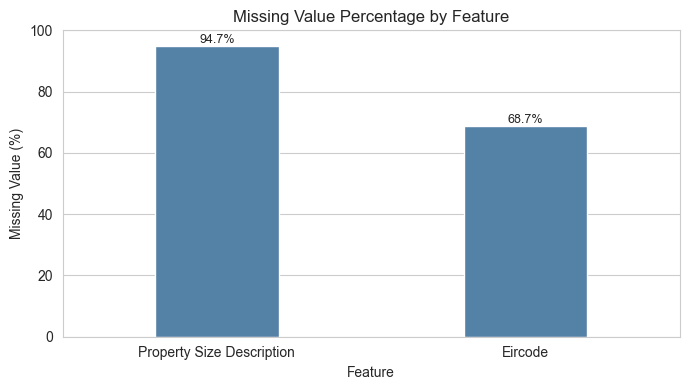

In [10]:
missing_pct_plot = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct_plot = missing_pct_plot[missing_pct_plot > 0]

plt.figure(figsize=(7, 4))
sns.barplot(x=missing_pct_plot.index, y=missing_pct_plot.values, color='steelblue', width=0.4)
plt.ylabel('Missing Value (%)')
plt.xlabel('Feature')
plt.title('Missing Value Percentage by Feature')
plt.ylim(0, 100)
for i, v in enumerate(missing_pct_plot.values):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

**Findings:**

The missingness is concentrated in exactly two features:

- **`Property Size Description`** (94.75% missing): Almost entirely absent from the dataset. This level of missingness makes the feature practically unusable without significant imputation, which would be unreliable given so few observed values.
- **`Eircode`** (68.72% missing): The Irish postcode system was only introduced in 2015, which explains the high rate of missing values for older transactions. Among the non-missing values, cardinality is extremely high (~16,823 unique values), making it unsuitable for direct use as a categorical feature.

All other features are **complete with 0% missing values**, indicating strong overall data integrity for the majority of fields.

### 1.8 Categorical Feature Distributions

We visualise the frequency distribution of each categorical feature to understand value concentration, class imbalance, and potential data quality issues.

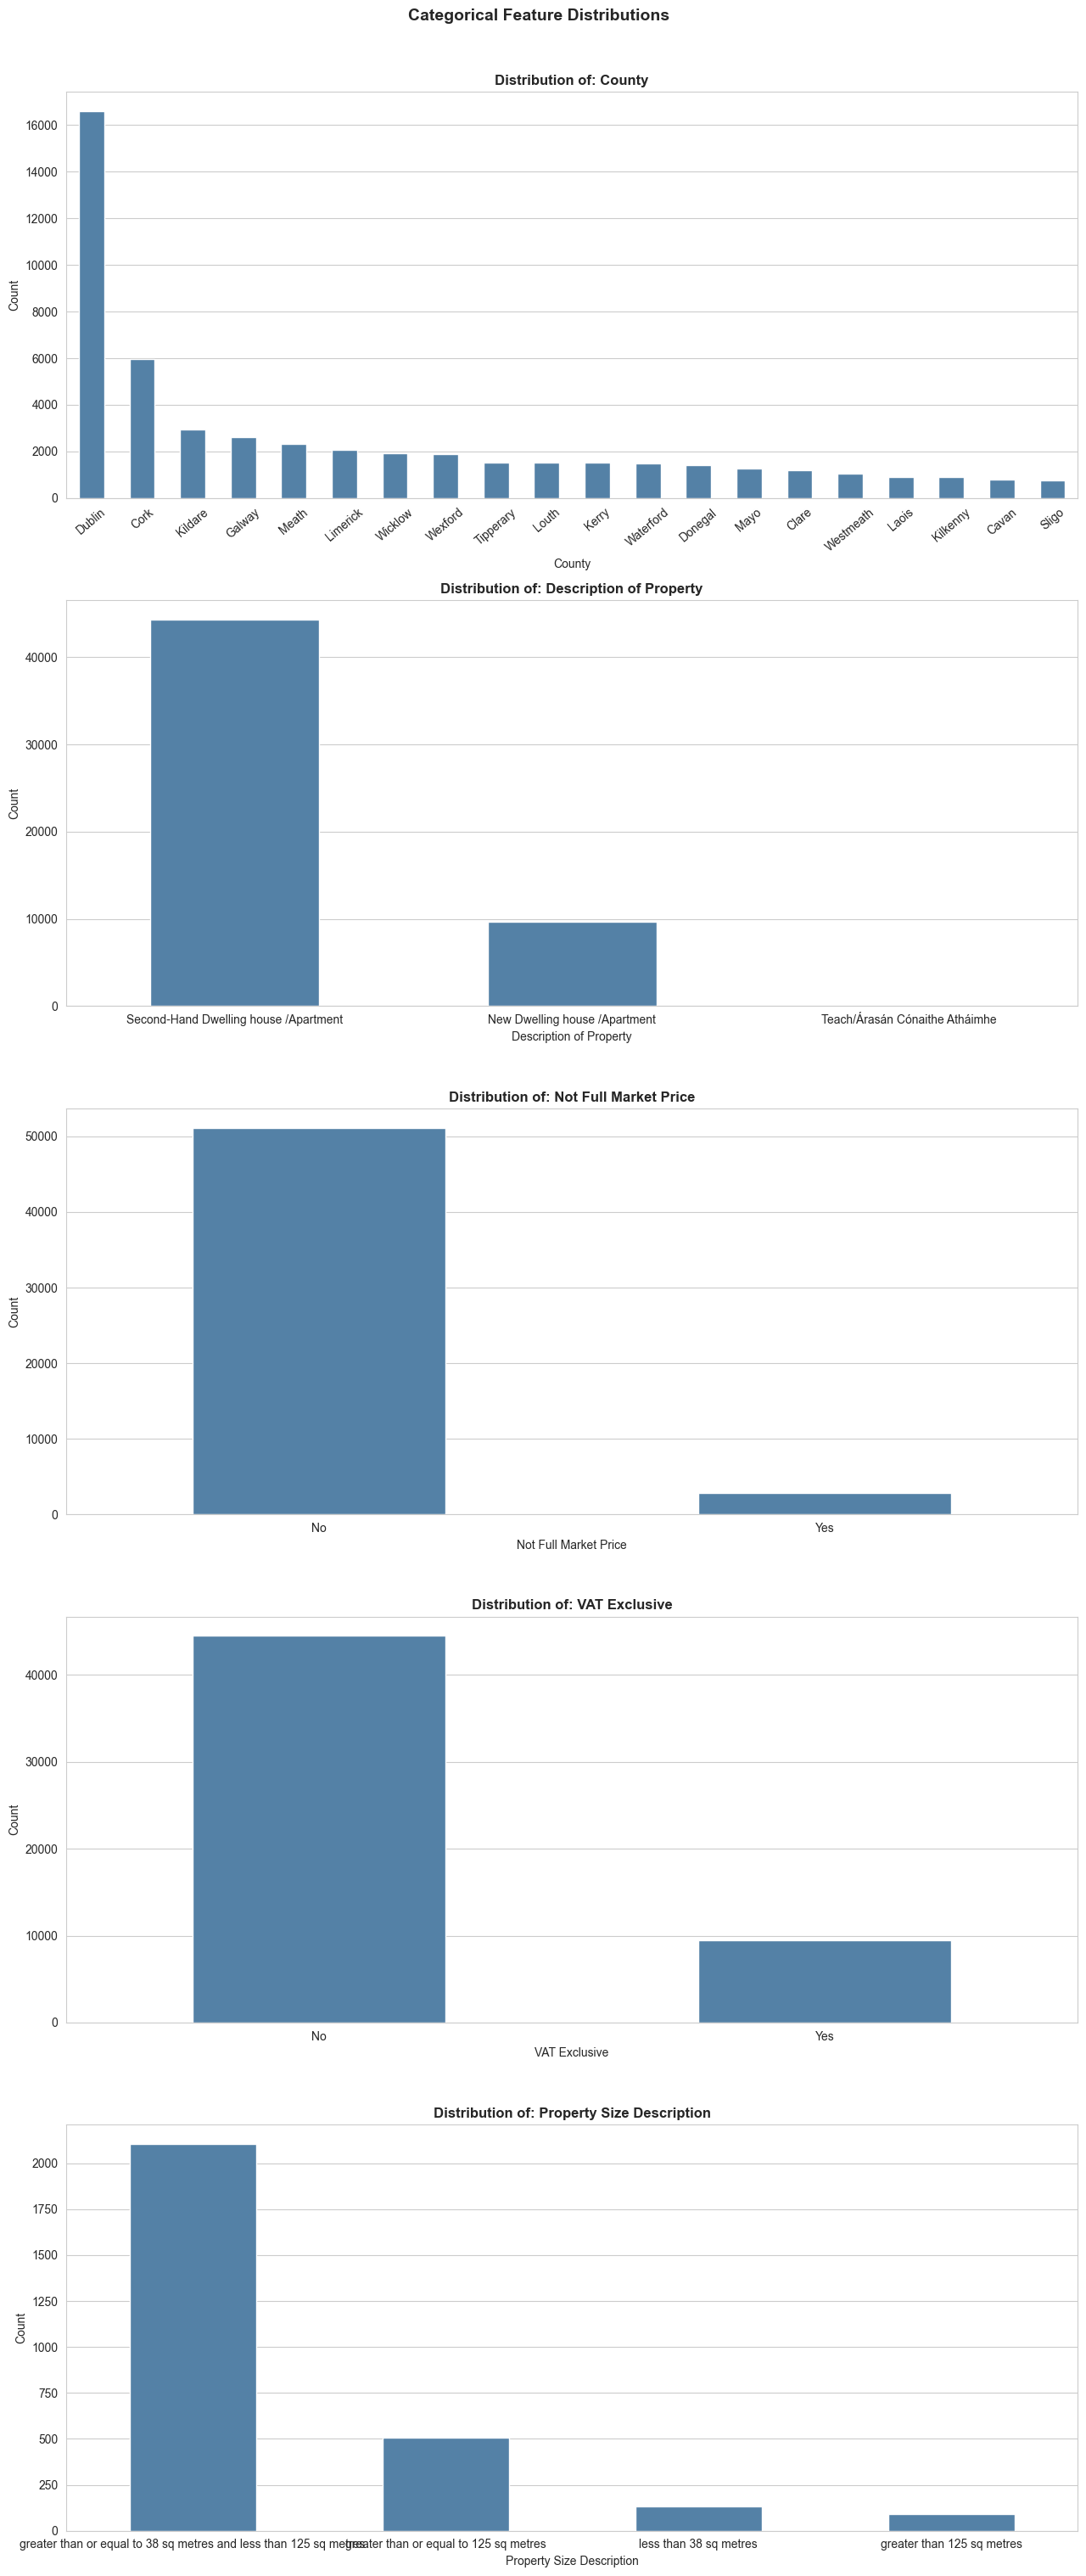

In [11]:
plot_cats = [
    'County', 'Description of Property', 'Not Full Market Price',
    'VAT Exclusive', 'Property Size Description'
]
plot_cats = [c for c in plot_cats if c in df.columns]

fig, axes = plt.subplots(len(plot_cats), 1, figsize=(13, 6 * len(plot_cats)), dpi=100)
if len(plot_cats) == 1:
    axes = [axes]

for ax, col in zip(axes, plot_cats):
    freq = df[col].value_counts(dropna=False)
    if len(freq) > 20:
        freq = freq.head(20)
    sns.barplot(x=freq.index.astype(str), y=freq.values, color='steelblue', width=0.5, ax=ax)
    ax.set_title(f'Distribution of: {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    if len(freq) > 8:
        ax.tick_params(axis='x', rotation=40)

plt.suptitle('Categorical Feature Distributions', y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Findings from Categorical Distributions:**

- **`County`**: Dublin dominates with ~30.7% of all transactions (16,592 records), followed by Cork (~11.1%) and Kildare (~5.4%). More rural counties such as Sligo, Cavan and Kilkenny account for fewer than 1,000 records each. This geographic imbalance means the model will be trained predominantly on urban transactions and may generalise less well to rural areas.
- **`Description of Property`**: Strongly dominated by "Second-Hand Dwelling house/Apartment" (~82.1%). New dwellings account for ~17.9%. A third category "Teach/Árasán Cónaithe Athámhe" (Irish language) appears in only 3 records — this is almost certainly a mislabelled second-hand property and should be standardised.
- **`Not Full Market Price`**: Heavily imbalanced — only ~5.3% of transactions are flagged as "Yes". These represent non-market sales (e.g., transfers between family members) which may not reflect true market value and could distort model training.
- **`VAT Exclusive`**: 17.6% of records report VAT-exclusive prices. Since VAT at 13.5% applies to new-build properties, these records **understate the true market price** — an important data quality issue to address before modelling.
- **`Property Size Description`**: Among the 2,835 non-missing records, the majority fall in the "38–125 sq metres" category. However, given the 94.75% missingness rate, the distribution shown here is not representative of the full dataset.

### 1.9 Price Distribution Analysis

As the target variable, understanding the distribution of `Price (€)` is critical. We examine:
1. The raw price distribution to assess skewness
2. The log-transformed price distribution to evaluate normality after transformation
3. A boxplot to visualise the spread and scale of outliers
4. Percentile and IQR-based price boundaries to quantify the extent of extreme values

In [12]:
price = df['Price (€)'].dropna()

# --- Percentile boundaries ---
quantiles = price.quantile([0.01, 0.02, 0.05, 0.25, 0.75, 0.95, 0.98, 0.99])
q1, q3 = quantiles[0.25], quantiles[0.75]
iqr = q3 - q1

print("=== Price Percentile Boundaries ===")
for pct in [0.01, 0.02, 0.05, 0.95, 0.98, 0.99]:
    print(f"  {int(pct*100):>2}th percentile: €{quantiles[pct]:>15,.2f}")

print(f"\n=== IQR-Based Boundaries ===")
print(f"  Q1          : €{q1:>15,.2f}")
print(f"  Q3          : €{q3:>15,.2f}")
print(f"  IQR         : €{iqr:>15,.2f}")
print(f"  Upper fence : €{q3 + 1.5*iqr:>15,.2f}")
print(f"  Lower fence : €{max(0, q1 - 1.5*iqr):>15,.2f}  (floored at 0)")

=== Price Percentile Boundaries ===
   1th percentile: €      27,000.00
   2th percentile: €      37,500.00
   5th percentile: €      60,000.00
  95th percentile: €     703,000.00
  98th percentile: €   1,000,000.00
  99th percentile: €   1,500,000.00

=== IQR-Based Boundaries ===
  Q1          : €     157,000.00
  Q3          : €     365,000.00
  IQR         : €     208,000.00
  Upper fence : €     677,000.00
  Lower fence : €           0.00  (floored at 0)


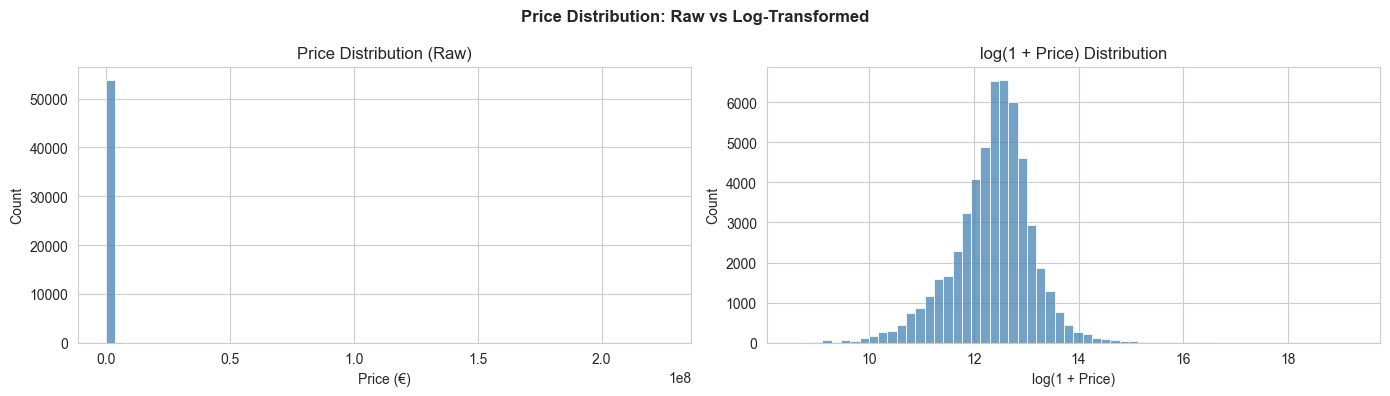

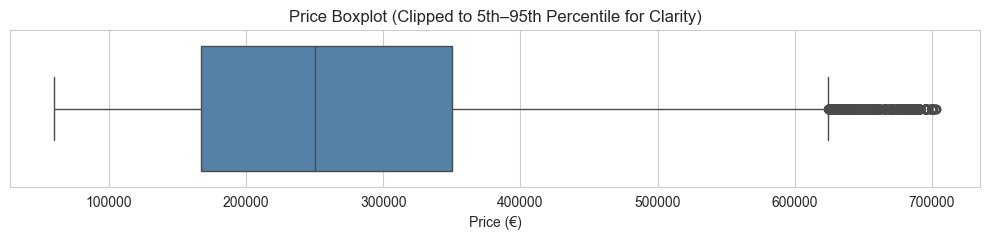

In [13]:
p5  = quantiles[0.05]
p95 = quantiles[0.95]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Raw distribution
sns.histplot(price, bins=60, color='steelblue', ax=axes[0])
axes[0].set_title('Price Distribution (Raw)')
axes[0].set_xlabel('Price (€)')
axes[0].set_ylabel('Count')

# Log-transformed
sns.histplot(np.log1p(price), bins=60, color='steelblue', ax=axes[1])
axes[1].set_title('log(1 + Price) Distribution')
axes[1].set_xlabel('log(1 + Price)')
axes[1].set_ylabel('Count')

plt.suptitle('Price Distribution: Raw vs Log-Transformed', fontweight='bold')
plt.tight_layout()
plt.show()

# Boxplot clipped to 5%-95% for clarity
plt.figure(figsize=(10, 2.5))
sns.boxplot(x=price[(price >= p5) & (price <= p95)], color='steelblue')
plt.title('Price Boxplot (Clipped to 5th–95th Percentile for Clarity)')
plt.xlabel('Price (€)')
plt.tight_layout()
plt.show()

**Findings — Price Distribution:**

- The **raw price distribution** is extremely right-skewed — the histogram is entirely compressed into the leftmost bin due to a small number of extremely high-value transactions (up to €225M). This confirms that the raw price cannot be used directly as a model target without transformation.
- After applying **`log(1 + Price)`**, the distribution becomes approximately bell-shaped and much more suitable for regression modelling. This transformation will be applied in the Data Quality Plan.
- The **boxplot** (clipped to the 5th–95th percentile range for clarity) shows that the central 90% of transactions fall between €60,000 and €703,000, with the IQR spanning €157,000 to €365,000. A large cluster of outliers is visible beyond the upper fence (€677,000).
- **Key actions for DQP**:
  - Use `log1p(Price)` as the model target to address skewness.
  - Investigate and potentially remove or cap extreme price outliers (e.g., bulk transactions above the 99th percentile of €1,500,000).
  - Investigate the minimum price of €5,250 — this is suspiciously low for a residential property.

### 1.10 Price Outlier Investigation

We inspect the top 20 highest-priced records to understand the nature of extreme values and determine whether they represent genuine single-property transactions or bulk/multi-unit sales.

In [14]:
top20 = df.nlargest(20, 'Price (€)')[
    ['Date of Sale (dd/mm/yyyy)', 'Address', 'County', 'Price (€)',
     'Description of Property', 'Not Full Market Price', 'VAT Exclusive']
]
print("Top 20 Records by Price:")
display(top20)

Top 20 Records by Price:


,Date of Sale (dd/mm/yyyy),Address,County,Price (€),Description of Property,Not Full Market Price,VAT Exclusive
46338,2023-02-10,"O'Devaney Gardens, Arbour Hill, Dublin 7",Dublin,2.250000e+08,New Dwelling house /Apartment,Yes,Yes
20370,2019-12-23,"Blocks A and C, The Point Campus",Dublin,1.422566e+08,New Dwelling house /Apartment,No,Yes
22259,2019-05-27,"Apartments 1-164 Fairwary Court, &amp; 1-50 Fa...",Dublin,9.524229e+07,New Dwelling house /Apartment,No,Yes
46850,2023-12-20,"Blocks D1 D2 D3 and D4, Cúil Dúin Avenue, Ci...",Dublin,9.251101e+07,New Dwelling house /Apartment,No,Yes
49087,2024-06-27,"Blocks 5A-5D (including basement), Belmayne Av...",Dublin,7.973568e+07,New Dwelling house /Apartment,No,Yes
49227,2024-02-12,"Barnwell Park, Hansfield",Dublin,7.886671e+07,New Dwelling house /Apartment,No,Yes
37610,2022-10-07,"Apartments 1 - 190, Balroy House, Carpentersto...",Dublin,7.407876e+07,New Dwelling house /Apartment,No,Yes
48859,2024-12-09,"BLOCK B, AIRTON PLAZA, TALLAGHT",Dublin,7.037500e+07,New Dwelling house /Apartment,No,Yes
17478,2018-07-27,"182 THE ELYSIAN, EGLINTON STREET, CORK",Cork,6.987348e+07,Second-Hand Dwelling house /Apartment,Yes,No
1716,2016-12-19,"Binary Hub Roe's Lane, Bonham Street",Dublin,6.920816e+07,New Dwelling house /Apartment,No,No


**Findings — Extreme Price Records:**

- All top 20 records have prices ranging from €28M to €225M — several orders of magnitude above the median of €250,000. These are clearly **not single residential property transactions**.
- The addresses confirm this: entries such as "Apartments 1-164 Fairway Court", "Blocks A and C, The Point Campus", and "Blocks D1 D2 D3 and D4" indicate **bulk purchases of entire residential developments**.
- The highest record (€225M, O'Devaney Gardens) is flagged as `Not Full Market Price = Yes`, further confirming it is not a standard open-market transaction.
- Almost all of these records are concentrated in **Dublin**, which explains part of Dublin's inflated mean price compared to its median.
- **Key action for DQP**: these bulk transactions are not representative of individual residential property sales and should be removed or capped before modelling, as they would severely distort any regression model trained on price.

### 1.11 Price Distribution by County

A boxplot of price by county reveals regional price variation — an important signal for the prediction model. Prices are clipped to the 95th percentile for visual clarity.

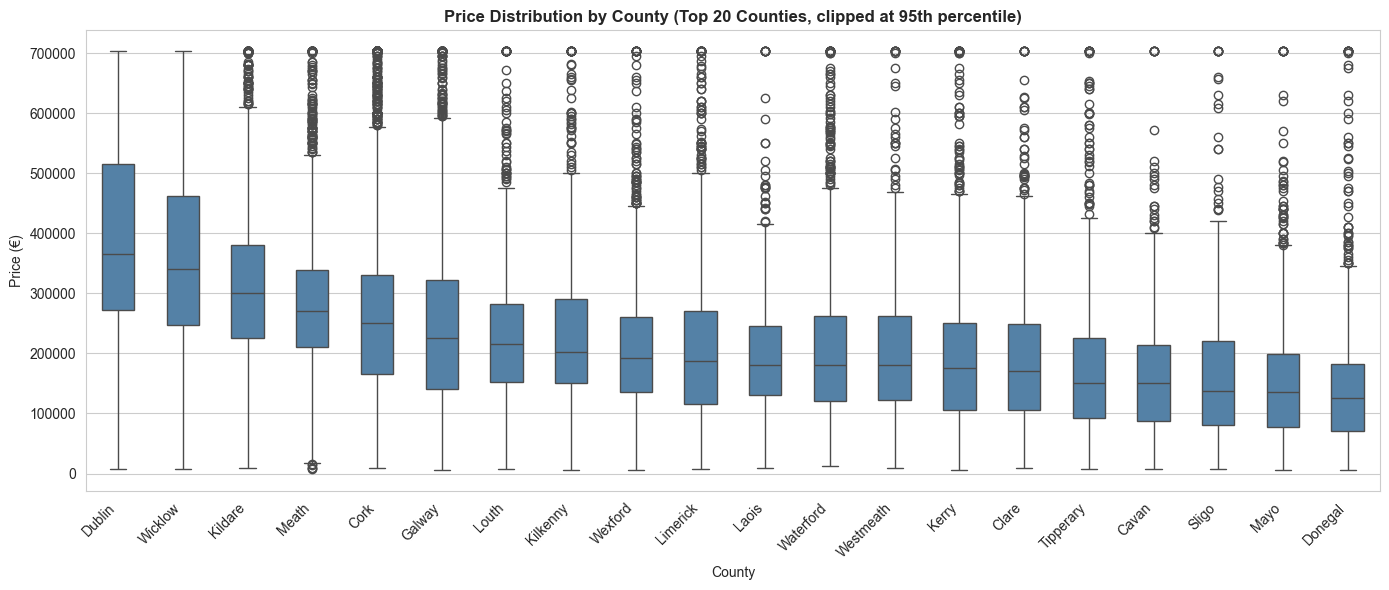

In [15]:
top_counties = df['County'].value_counts(dropna=True).head(20).index
tmp = df[df['County'].isin(top_counties)].copy()

# Clip prices to 95th percentile for plot clarity
p95_val = df['Price (€)'].quantile(0.95)
tmp['Price_clipped'] = tmp['Price (€)'].clip(upper=p95_val)

county_order = tmp.groupby('County', observed=True)['Price_clipped']\
                  .median().sort_values(ascending=False).index

plt.figure(figsize=(14, 6))
sns.boxplot(data=tmp, x='County', y='Price_clipped',
            order=county_order, color='steelblue', width=0.5)
plt.title('Price Distribution by County (Top 20 Counties, clipped at 95th percentile)',
          fontweight='bold')
plt.xlabel('County')
plt.ylabel('Price (€)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Findings — Price by County:**

- There is a clear and strong **geographic price gradient** across Irish counties.
- **Dublin** has the highest median price (≈ €360,000), followed by **Wicklow** (≈ €340,000) and **Kildare** (≈ €295,000) — both Dublin commuter belt counties. This pattern is consistent with the well-documented urban premium in the Irish property market.
- **Donegal**, **Mayo**, and **Sligo** show the lowest median prices (below €150,000), reflecting the lower demand and more rural character of these counties.
- Outliers are present in every county, but are particularly numerous in Dublin, Cork, and Kildare — likely reflecting a mix of high-end individual properties and bulk transactions.
- `County` is clearly a **strong predictor of price** and should be retained as a key feature in the model. An appropriate encoding strategy (e.g., target encoding or one-hot encoding) will be decided in the DQP.

### 1.12 Price Trend Over Time

We examine how median sale prices evolve by year and by month to detect temporal patterns that may be useful for prediction.

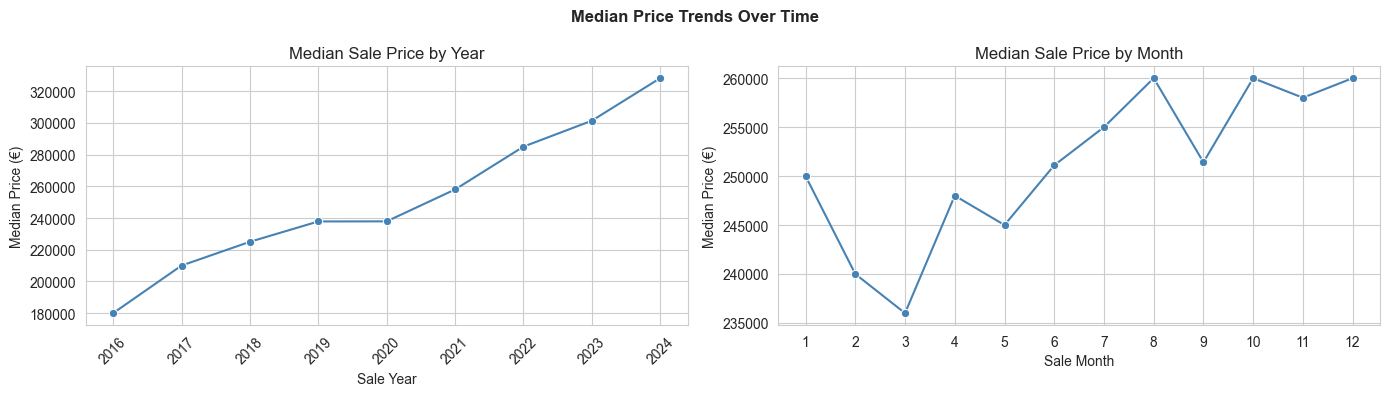

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# By Year
yr = (df.dropna(subset=['Price (€)', 'Sale Year'])
        .groupby('Sale Year', observed=False)['Price (€)']
        .median()
        .sort_index())
sns.lineplot(x=yr.index.astype(str), y=yr.values, marker='o',
             color='steelblue', ax=axes[0])
axes[0].set_title('Median Sale Price by Year')
axes[0].set_xlabel('Sale Year')
axes[0].set_ylabel('Median Price (€)')
axes[0].tick_params(axis='x', rotation=45)

# By Month
mo = (df.dropna(subset=['Price (€)', 'Sale Month'])
        .groupby('Sale Month', observed=False)['Price (€)']
        .median()
        .sort_index())
sns.lineplot(x=mo.index.astype(str), y=mo.values, marker='o',
             color='steelblue', ax=axes[1])
axes[1].set_title('Median Sale Price by Month')
axes[1].set_xlabel('Sale Month')
axes[1].set_ylabel('Median Price (€)')

plt.suptitle('Median Price Trends Over Time', fontweight='bold')
plt.tight_layout()
plt.show()

**Findings — Price Trends Over Time:**

- **By Year**: Median prices show a clear and consistent **upward trend** from €181,000 in 2016 to €328,000 in 2024 — an increase of approximately 81% over 8 years. The slight flattening in 2019–2020 may reflect the impact of COVID-19 on market activity. The acceleration from 2021 onwards is consistent with the well-documented post-pandemic surge in Irish property prices driven by supply constraints and increased demand.
- **By Month**: There is a modest but visible **seasonal pattern**. Prices dip in Q1 (January–March), reach a local peak in summer (July–August), dip again in September, then recover towards year-end. This likely reflects buyer activity patterns — fewer transactions in winter months, more in spring and summer.
- Both `Sale Year` and `Sale Month` capture meaningful temporal signal and will be retained as features. `Sale Year` in particular is strongly correlated with price and may be one of the most important predictors in the model.

### 1.13 VAT Consistency Check

In Ireland, VAT at 13.5% applies to new-build residential properties. Therefore, records with `VAT Exclusive = Yes` should logically correspond only to `Description of Property = "New Dwelling house/Apartment"`. We verify whether any `VAT Exclusive = No` records are classified as "New Dwelling" — which would represent a logical inconsistency in the data.

In [17]:
vat_no = df[df['VAT Exclusive'].astype(str) == 'No'].copy()
desc_dist = (vat_no['Description of Property']
             .value_counts(dropna=False)
             .rename_axis('Description of Property')
             .reset_index(name='count'))
desc_dist['pct_%'] = (desc_dist['count'] / len(vat_no) * 100).round(2)

print(f"Records with VAT Exclusive = 'No': {len(vat_no):,}")
print("\nDescription of Property breakdown within VAT Exclusive = No:")
display(desc_dist)

# Flag inconsistent records
inconsistent = vat_no[
    vat_no['Description of Property'].astype(str).str.strip()
    == 'New Dwelling house /Apartment'
]
print(f"\nLogically inconsistent records (VAT=No but New Dwelling): {len(inconsistent)}")
display(inconsistent[['Date of Sale (dd/mm/yyyy)', 'County', 'Price (€)',
                       'Description of Property', 'VAT Exclusive']].head(10))

Records with VAT Exclusive = 'No': 44,478

Description of Property breakdown within VAT Exclusive = No:


,Description of Property,count,pct_%
0,Second-Hand Dwelling house /Apartment,44324,99.65
1,New Dwelling house /Apartment,151,0.34
2,Teach/Árasán Cónaithe Atháimhe,3,0.01



Logically inconsistent records (VAT=No but New Dwelling): 151


,Date of Sale (dd/mm/yyyy),County,Price (€),Description of Property,VAT Exclusive
167,2016-05-10,Wicklow,375000.0,New Dwelling house /Apartment,No
316,2016-06-16,Kerry,100000.0,New Dwelling house /Apartment,No
1182,2016-09-29,Kilkenny,160000.0,New Dwelling house /Apartment,No
1615,2016-09-08,Louth,220000.0,New Dwelling house /Apartment,No
1716,2016-12-19,Dublin,69208163.0,New Dwelling house /Apartment,No
1862,2016-07-08,Dublin,55500.0,New Dwelling house /Apartment,No
2047,2016-08-30,Dublin,1115000.0,New Dwelling house /Apartment,No
2305,2016-11-18,Meath,125500.0,New Dwelling house /Apartment,No
2502,2016-12-19,Cork,327000.0,New Dwelling house /Apartment,No
2739,2016-05-30,Kerry,60312.0,New Dwelling house /Apartment,No


**Findings — VAT Consistency:**

- Among the 44,478 records where `VAT Exclusive = No`, **151 records** are classified as "New Dwelling house/Apartment" — a logical contradiction, since new builds in Ireland should attract VAT at 13.5%.
- These 151 inconsistent records (≈ 0.34% of the dataset) are concentrated in earlier years (2016), suggesting they may reflect data entry errors or edge cases in the RPPR reporting system at the time.
- Additionally, **3 records** use the Irish-language label `Teach/Árasán Cónaithe Atháimhe` — these are almost certainly second-hand dwellings and should be standardised to the English label.
- **Key actions for DQP**:
  - Flag and investigate the 151 logically inconsistent VAT records.
  - Standardise the 3 Irish-language labels to "Second-Hand Dwelling house/Apartment".
  - For valid `VAT Exclusive = Yes` new-build records, consider creating a VAT-adjusted price column: `Price × 1.135` to reflect the true market value.

### 1.14 Export DQR Summary Tables

We save the numeric and categorical DQR summary tables as CSV files for inclusion in the DQR PDF report appendix.

In [18]:
numeric_dqr.to_csv('DQR-NumericFeatures.csv', index_label='Feature')
categorical_dqr.to_csv('DQR-CategoricalFeatures.csv', index_label='Feature')

print("DQR summary tables saved:")
print("  → DQR-NumericFeatures.csv")
print("  → DQR-CategoricalFeatures.csv")

DQR summary tables saved:
  → DQR-NumericFeatures.csv
  → DQR-CategoricalFeatures.csv


### 1.15 DQR Summary of Key Findings

This section consolidates all findings from the analysis above into a structured summary, suitable for inclusion in the DQR PDF report.

#### Missing Value Issues

| Feature | Missing % | Severity | Proposed Action |
|---|---|---|---|
| `Property Size Description` | 94.75% | 🔴 Critical | Drop column — too few observed values to impute reliably |
| `Eircode` | 68.72% | 🔴 High | Extract district-level prefix; drop raw field |

#### Structural Issues

| Issue | Detail | Proposed Action |
|---|---|---|
| Duplicate rows | 9 found and removed | Resolved |
| Constant columns | 0 found | No action needed |
| Duplicate column pairs | 0 found | No action needed |
| High cardinality: `Address` | 53,261 unique values | Use a geocoding API to convert raw address strings into administrative districts (e.g., Dublin 1, Dublin 2, or county-level subdivision), then encode as a categorical feature |
| High cardinality: `Eircode` | 16,823 unique values | Engineer district-level feature before dropping |

#### Distribution & Outlier Issues

| Feature | Issue | Proposed Action |
|---|---|---|
| `Price (€)` | Strongly right-skewed | Apply `log1p` transformation for modelling |
| `Price (€)` | Bulk transactions (max €225M) | Remove records above 99th percentile (€1.5M) |
| `Price (€)` | Suspicious minimum (€5,250) | Investigate; apply lower-bound threshold |
| `Not Full Market Price` | 94.7% "No" — imbalanced | Retain; consider filtering "Yes" records before modelling |

#### Logical Consistency Issues

| Issue | Records Affected | Proposed Action |
|---|---|---|
| `VAT Exclusive = No` + `New Dwelling` | 151 records | Flag and investigate; correct where possible |
| Irish-language label in `Description of Property` | 3 records | Reclassify as "Second-Hand Dwelling house/Apartment" |
| `VAT Exclusive = Yes` new builds | ~9,513 records | Create VAT-adjusted price: `Price × 1.135` |

#### Feature Usability Summary

| Feature | Type | Quality | Recommended Action |
|---|---|---|---|
| `Date of Sale` | datetime | ✅ Clean | Extract `Sale Year` and `Sale Month` |
| `Price (€)` | float | ⚠️ Skewed + outliers | Log-transform; cap extremes |
| `County` | category | ✅ Clean | Retain; encode for modelling |
| `Description of Property` | category | ⚠️ 3 mislabelled records | Fix labels; retain |
| `VAT Exclusive` | category | ⚠️ 151 inconsistencies | Fix inconsistencies; retain |
| `Not Full Market Price` | category | ⚠️ Imbalanced | Retain; monitor impact on model |
| `Eircode` | string | 🔴 68.7% missing | Engineer district prefix; drop raw field |
| `Address` | string | 🔴 High cardinality | Use geocoding API to extract administrative district; encode as categorical feature |
| `Property Size Description` | category | 🔴 94.75% missing | Drop column |
| `Sale Year` | int | ✅ Clean | Retain as numeric feature |
| `Sale Month` | int | ✅ Clean | Retain as numeric feature |

## Part 2: Data Quality Plan (DQP)

### Overview

The Data Quality Plan (DQP) implements the cleaning strategies identified in the DQR (Part 1). All transformations are applied exclusively to the **training set**, starting from the raw CSV file.

The DQP covers the following steps:
1. Address feature engineering — convert raw address strings into a `location_category` feature: Dublin properties are mapped to fine-grained postal districts (e.g., `Dublin_4`, `Dublin_15`) via a geocoding pipeline; non-Dublin properties retain their `County` as the location label. The geocoded result is pre-computed offline and loaded directly in Step 2. For full details of the geocoding methodology, see **DQP.pdf**.
2. Load geocoded data and perform baseline check
3. Basic standardisation (whitespace, date parsing, price conversion)
4. Drop empty/constant/duplicate columns and rows
5. Core field validation (price, date, county)
6. VAT price adjustment for new-build properties
7. Price clamping to remove extreme outliers
8. Handle high-missingness columns (`Eircode`, `Property Size Description`)
9. Fill remaining missing values
10. Post-clean validation and export

A cleaning log is maintained throughout to record the effect of each step on the dataset shape.

> **Note**: The test set will undergo the same cleaning pipeline in Part 5. Parameters fitted on the training set (e.g., quantile boundaries for price clamping) will be reused on the test set without refitting, to prevent data leakage.

### 2.1 Address Feature Engineering — Offline Geocoding Pipeline

The raw `Address` field contains over 53,000 near-unique string values and cannot be used directly as a categorical feature. To extract meaningful location signal, we ran an **offline geocoding pipeline** on the training set prior to this notebook, producing `geocoded_train.csv`.

The pipeline works as follows: for each Dublin property, the raw address string is first converted to geographic coordinates (latitude/longitude) via forward geocoding using the Nominatim (OpenStreetMap) API, with Mapbox as a fallback when Nominatim returns no result. The resulting coordinates are then passed to a reverse geocoding step to extract the Dublin postal district (e.g., `Dublin 4`, `Dublin 15`) from the returned postcode. For Dublin rows where reverse geocoding fails to resolve a district, a geometric rule based on a fixed reference point `(53.3464, -6.3382)` is applied to assign the row to one of three broad western/north-eastern/south-eastern zones (Districts 25, 26, 27). The pipeline output is validated visually using interactive Leaflet maps at both intermediate and final stages. Non-Dublin properties are not geocoded and retain their `County` directly.

The final `location_category` feature is constructed by combining Dublin district labels and County labels into a single categorical variable:
- Dublin properties → `Dublin_4`, `Dublin_15`, `Dublin_6W`, etc.
- Non-Dublin properties → `Cork`, `Galway`, `Wicklow`, etc.

For the full methodology and justification, see **DQP.pdf**.

In [19]:
from pathlib import Path

geocoded_path = Path('geocoded_train.csv')

df_raw = pd.read_csv(geocoded_path, encoding='utf-8')

print(f"Loaded: {geocoded_path}")
print(f"Shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns\n")
print("Columns:", df_raw.columns.tolist())
display(df_raw.head(3))

Loaded: geocoded_train.csv
Shape: 54000 rows × 14 columns

Columns: ['Date of Sale (dd/mm/yyyy)', 'Address', 'County', 'Eircode', 'Price (€)', 'Not Full Market Price', 'VAT Exclusive', 'Description of Property', 'Property Size Description', 'geocode_status', 'latitude', 'longitude', 'geocode_provider', 'dublin_district']


,Date of Sale (dd/mm/yyyy),Address,County,Eircode,Price (€),Not Full Market Price,VAT Exclusive,Description of Property,Property Size Description,geocode_status,latitude,longitude,geocode_provider,dublin_district
0,30/09/2016,"28 BRACKEN COURT, DONNYBROOK, CORK",Cork,NaN,"€181,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,NaN,NaN,NaN,NaN,NaN
1,20/12/2016,"2 AN CLOCHAR, CONVENT RD, DONERAILE",Cork,NaN,"€50,152.49",No,Yes,New Dwelling house /Apartment,less than 38 sq metres,NaN,NaN,NaN,NaN,NaN
2,28/09/2016,"Apartment 7 The Court, Clonattin, Gorey",Wexford,NaN,"€62,171.81",No,Yes,New Dwelling house /Apartment,greater than or equal to 38 sq metres and less...,NaN,NaN,NaN,NaN,NaN


### 2.2 Baseline Check

We perform a quick baseline check on the loaded geocoded dataset before any cleaning — recording shape, data types, missing values, and duplicate rows. This serves as the "before cleaning" reference point for the cleaning log.

In [20]:
from dataclasses import dataclass, field

@dataclass
class DQLog:
    steps: list = field(default_factory=list)

    def add(self, step: str, before_shape, after_shape, notes: str = ""):
        br, bc = before_shape
        ar, ac = after_shape
        self.steps.append({
            "step"        : step,
            "rows_before" : br, "rows_after" : ar, "rows_delta" : ar - br,
            "cols_before" : bc, "cols_after" : ac, "cols_delta" : ac - bc,
            "notes"       : notes
        })

    def to_frame(self):
        return pd.DataFrame(self.steps)

log = DQLog()

print("=== Baseline Check (Before Cleaning) ===")
print(f"Shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")

print("\nData types:")
display(df_raw.dtypes.to_frame('dtype'))

print("\nMissing values:")
missing = df_raw.isna().sum().sort_values(ascending=False)
missing_pct = (df_raw.isna().mean() * 100).sort_values(ascending=False)
display(pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct.round(2)}))

print(f"\nDuplicate rows: {df_raw.duplicated().sum()}")

=== Baseline Check (Before Cleaning) ===
Shape: 54000 rows × 14 columns

Data types:


,dtype
Date of Sale (dd/mm/yyyy),str
Address,str
County,str
Eircode,str
Price (€),str
Not Full Market Price,str
VAT Exclusive,str
Description of Property,str
Property Size Description,str
geocode_status,str



Missing values:


,missing_count,missing_%
Property Size Description,51164,94.75
latitude,37416,69.29
longitude,37416,69.29
geocode_provider,37416,69.29
dublin_district,37416,69.29
geocode_status,37408,69.27
Eircode,37108,68.72
Date of Sale (dd/mm/yyyy),0,0.00
Address,0,0.00
County,0,0.00



Duplicate rows: 9


**Baseline Observations:**

- The geocoded dataset has 54,000 rows and 14 columns — the original 9 columns plus 5 geocoding columns added by the pipeline (`geocode_status`, `latitude`, `longitude`, `geocode_provider`, `dublin_district`).
- The geocoding columns are only populated for Dublin rows (~30.7% of the dataset). All non-Dublin rows have `NaN` in these columns by design, as the pipeline only geocoded Dublin addresses.
- `Property Size Description` remains 94.75% missing — consistent with the DQR findings.
- `Eircode` is 68.72% missing — also consistent with DQR.
- All other original columns are fully complete.

We now proceed with the cleaning pipeline on a copy of this dataframe.

In [21]:
df = df_raw.copy()


### 2.3 Drop Duplicate Rows

We remove duplicate rows before dropping the `Address` column to ensure we are identifying true duplicates — records that are identical across all original fields including the raw address string. Performing deduplication after dropping `Address` would incorrectly flag records that share the same county, price and date but have different addresses as duplicates.

In [22]:
before = df.shape

dup_count = int(df.duplicated().sum())
df = df.drop_duplicates(keep='first').reset_index(drop=True)

after = df.shape
log.add('Drop duplicate rows', before, after, f'dup_rows_removed={dup_count}')

print(f"Duplicate rows removed: {dup_count}")
print(f"Shape after           : {df.shape}")

Duplicate rows removed: 9
Shape after           : (53991, 14)


### 2.4 Drop Geocoding Auxiliary Columns

The columns `geocode_status`, `latitude`, `longitude`, and `geocode_provider` were added by the offline geocoding pipeline for quality checking purposes only. They are not features of the original dataset and carry no direct predictive value. We drop them now before proceeding with the cleaning pipeline, retaining only `dublin_district` which will be used to construct the final `location_category` feature. The raw `Address` column is also dropped at this stage as it has been fully superseded by `dublin_district`.

### 2.4.1 Extract `is_apartment` from Address

Before dropping the raw `Address` column, we extract one binary feature:
- **`is_apartment`**: 1 if the address contains keywords such as "apartment", "apt", "unit", or "flat"; 0 otherwise.

This feature captures whether the property is an apartment-style dwelling, which is a useful signal for price prediction — apartments typically command different prices than houses.

In [23]:
before = df.shape

df['is_apartment'] = df['Address'].str.contains(
    r'\b(apartment|apt|unit|flat)\b', case=False, na=False
).astype(int)

after = df.shape
log.add('Extract is_apartment from Address', before, after,
        f'apartment_count={int(df["is_apartment"].sum())}')

print(f"is_apartment = 1 : {df['is_apartment'].sum():,} records ({df['is_apartment'].mean()*100:.1f}%)")
print(f"is_apartment = 0 : {(df['is_apartment'] == 0).sum():,} records")

is_apartment = 1 : 3,090 records (5.7%)
is_apartment = 0 : 50,901 records


/var/folders/lm/1wz6n56157b9hqw0yth0p3j40000gn/T/ipykernel_31943/1038967669.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['is_apartment'] = df['Address'].str.contains(


In [24]:
before = df.shape

drop_cols = ['geocode_status', 'latitude', 'longitude', 'geocode_provider', 'Address']
drop_cols = [c for c in drop_cols if c in df.columns]

df = df.drop(columns=drop_cols)

after = df.shape
log.add('Drop geocoding auxiliary columns and raw Address',
        before, after, f'dropped={drop_cols}')

print(f"Dropped columns: {drop_cols}")
print(f"Shape after    : {df.shape}")
print("\nCurrent columns:", df.columns.tolist())

Dropped columns: ['geocode_status', 'latitude', 'longitude', 'geocode_provider', 'Address']
Shape after    : (53991, 10)

Current columns: ['Date of Sale (dd/mm/yyyy)', 'County', 'Eircode', 'Price (€)', 'Not Full Market Price', 'VAT Exclusive', 'Description of Property', 'Property Size Description', 'dublin_district', 'is_apartment']


### 2.5 Basic Standardisation

We apply the following transformations:
- **Whitespace normalisation**: trim and collapse spaces in all string columns.
- **Date parsing**: convert `Date of Sale (dd/mm/yyyy)` to `datetime`.
- **Price parsing**: strip `€` and commas from `Price (€)`, convert to `float64`.
- **Temporal features**: derive `Sale Year` and `Sale Month` as numeric integers.
- **Categorical conversion**: convert low-cardinality text fields to `category` dtype.

In [25]:
before = df.shape

# --- Whitespace normalisation ---
str_cols = [c for c in df.columns if df[c].dtype == 'object']
for c in str_cols:
    df[c] = df[c].apply(clean_whitespace)

# --- Date parsing ---
date_col  = 'Date of Sale (dd/mm/yyyy)'
price_col = 'Price (€)'

df[date_col] = pd.to_datetime(df[date_col], dayfirst=True, errors='coerce')

# --- Price parsing ---
raw_price = df[price_col].astype(str).str.strip()
df[price_col] = pd.to_numeric(
    raw_price.str.replace('€', '', regex=False).str.replace(',', '', regex=False),
    errors='coerce'
)

# --- Temporal features ---
df['Sale Year']  = df[date_col].dt.year.astype('Int64')
df['Sale Month'] = df[date_col].dt.month.astype('Int64')

# --- Categorical conversion ---
cat_fields = [
    'County', 'Not Full Market Price', 'VAT Exclusive',
    'Description of Property', 'Property Size Description',
    'dublin_district'
]
for c in cat_fields:
    if c in df.columns:
        df[c] = df[c].astype('category')

after = df.shape
log.add('Basic standardisation (whitespace, date, price, temporal, category)',
        before, after)

print('Updated data types:')
display(df.dtypes.to_frame('dtype'))

Updated data types:


,dtype
Date of Sale (dd/mm/yyyy),datetime64[us]
County,category
Eircode,str
Price (€),float64
Not Full Market Price,category
VAT Exclusive,category
Description of Property,category
Property Size Description,category
dublin_district,category
is_apartment,int64


### 2.6 Construct `location` Feature

We combine `County` and `dublin_district` into a single categorical feature called `location`:
- If `County == "Dublin"`: `location` = `"Dublin_" + dublin_district` (e.g., `Dublin_4`, `Dublin_15`)
- Otherwise: `location` = `County` (e.g., `Cork`, `Galway`)

This produces a unified location feature that captures fine-grained postal district information for Dublin properties while retaining county-level information for all other properties. Once constructed, the raw `County` and `dublin_district` columns are dropped.

In [26]:
before = df.shape

def build_location(row):
    county = str(row['County']).strip()
    district = str(row['dublin_district']).strip()
    if county.lower() == 'dublin' and district not in ('', 'nan', 'None'):
        return f'Dublin_{district}'
    return county

df['location'] = df.apply(build_location, axis=1).astype('category')

# Drop the now-redundant columns
df = df.drop(columns=['County', 'dublin_district'])

after = df.shape
log.add('Construct location feature from County + dublin_district',
        before, after,
        'Dublin rows -> Dublin_<district>; non-Dublin rows -> County')

print("location value counts (top 20):")
display(df['location'].value_counts().head(20).to_frame('count'))
print(f"\nTotal unique location categories: {df['location'].nunique()}")
print(f"Shape after: {df.shape}")

location value counts (top 20):


,count
location,
Cork,5973
Kildare,2925
Galway,2598
Meath,2325
Limerick,2063
Dublin_26,2000
Wicklow,1924
Wexford,1883
Tipperary,1538



Total unique location categories: 51
Shape after: (53991, 11)


**Findings:**

- The `location` feature has **51 unique categories**: 25 non-Dublin counties plus 26 Dublin postal districts (e.g., `Dublin_4`, `Dublin_15`, `Dublin_26`).
- Cork (5,973), Kildare (2,925), and Galway (2,598) are the most common non-Dublin locations.
- Among Dublin districts, `Dublin_26` (2,000), `Dublin_27` (1,434), and `Dublin_15` (1,393) are the most frequent — note that Districts 25/26/27 are the geometric fallback categories assigned to Dublin rows where reverse geocoding could not resolve a specific postal district.
- This feature successfully replaces both the raw `Address` (too high cardinality) and the coarse `County` field for Dublin properties, providing a much more informative location signal for price prediction.

### 2.7 Core Field Validation

We apply basic validity filters to ensure the dataset only contains well-formed records:
- `Price (€)` must be a positive number (non-null and > 0).
- `Date of Sale` must be a valid parseable date (non-null).
- `location` must be non-empty.

Any records failing these checks are removed and logged.

In [27]:
before = df.shape

reject_mask = pd.Series(False, index=df.index)

# Price must be positive
reject_mask |= df[price_col].isna() | (df[price_col] <= 0)

# Date must be valid
reject_mask |= df[date_col].isna()

# Location must be non-empty
reject_mask |= df['location'].isna() | (df['location'].astype(str).str.strip() == '')

reject_count = int(reject_mask.sum())
df_rejected  = df.loc[reject_mask].copy()
df           = df.loc[~reject_mask].copy().reset_index(drop=True)

after = df.shape
log.add('Core field validation (price > 0, valid date, non-empty location)',
        before, after, f'rejected_rows={reject_count}')

print(f"Rejected rows : {reject_count}")
print(f"Shape after   : {df.shape}")
if reject_count > 0:
    print("\nRejected records sample:")
    display(df_rejected.head(10))

Rejected rows : 0
Shape after   : (53991, 11)


**Findings:**

- **0 records** were rejected by the core field validation checks.
- All 53,991 records have a valid positive price, a parseable date, and a non-empty location category.
- The dataset is structurally sound and ready for the remaining cleaning steps.

### 2.8 VAT Price Adjustment

In Ireland, VAT at 13.5% applies to new-build residential properties. Records where `Description of Property == "New Dwelling house /Apartment"` and `VAT Exclusive == "Yes"` report a VAT-exclusive price — meaning the declared price **understates the true market value** by 13.5%.

Our strategy:
- Retain the original `Price (€)` column for auditability.
- Create a new column `Price_Adjusted_VAT`: for qualifying new-build VAT-exclusive records, apply `Price × 1.135`; all other records retain their original price.
- Create a binary flag `vat_adjusted_flag` to mark which records were adjusted.

This ensures all prices are on a consistent VAT-inclusive basis before further processing.

In [28]:
before = df.shape

VAT_RATE = 0.135

vat_cond = (
    (df['Description of Property'].astype(str).str.strip() == 'New Dwelling house /Apartment') &
    (df['VAT Exclusive'].astype(str).str.strip().str.lower() == 'yes') &
    (df[price_col].notna())
)

df['Price_Adjusted_VAT'] = df[price_col].copy()
df.loc[vat_cond, 'Price_Adjusted_VAT'] = df.loc[vat_cond, price_col] * (1 + VAT_RATE)
df['vat_adjusted_flag'] = vat_cond.astype(int)

affected = int(vat_cond.sum())

after = df.shape
log.add('VAT price adjustment: create Price_Adjusted_VAT + vat_adjusted_flag',
        before, after, f'VAT_RATE={VAT_RATE}, affected_rows={affected}')

print(f"Records adjusted (VAT applied) : {affected}")
print(f"Records unchanged              : {len(df) - affected}")
print(f"Shape after                    : {df.shape}")

Records adjusted (VAT applied) : 9513
Records unchanged              : 44478
Shape after                    : (53991, 13)


**Findings:**

- **9,513 records** (17.6% of the dataset) had VAT applied — these are new-build properties reported at VAT-exclusive prices. Their adjusted prices are now on a consistent VAT-inclusive basis with the rest of the dataset.
- **44,478 records** retain their original price unchanged.
- The original `Price (€)` column is preserved for auditability. `Price_Adjusted_VAT` will be used as the working price column for all downstream steps including price clamping and modelling.

### 2.9 Price Clamping

The DQR identified that `Price (€)` is strongly right-skewed with extreme outliers (max = €225M) driven by bulk multi-unit transactions. We apply **percentile clamping** to `Price_Adjusted_VAT` to limit the influence of these extreme values:

- The 5th and 95th percentiles are computed on the **training set only** and stored for reuse on the test set (to prevent data leakage).
- A new column `Price_Final` is created as the clamped version of `Price_Adjusted_VAT`.
- The original `Price (€)` and `Price_Adjusted_VAT` columns are retained for auditability.

`Price_Final` will be used as the target variable for modelling in Part 5.

In [29]:
before = df.shape

# Compute boundaries on training set only — store for reuse on test set
p05 = df['Price_Adjusted_VAT'].quantile(0.05)
p95 = df['Price_Adjusted_VAT'].quantile(0.95)

df['Price_Final'] = df['Price_Adjusted_VAT'].clip(lower=p05, upper=p95)

clamped_count = int((
    (df['Price_Adjusted_VAT'] < p05) | (df['Price_Adjusted_VAT'] > p95)
).sum())

after = df.shape
log.add('Price clamping: create Price_Final (p05–p95 of Price_Adjusted_VAT)',
        before, after,
        f'p05={p05:.2f}, p95={p95:.2f}, clamped_rows={clamped_count}')

print(f"5th  percentile (lower bound) : €{p05:,.2f}")
print(f"95th percentile (upper bound) : €{p95:,.2f}")
print(f"Records clamped               : {clamped_count}")
print(f"Shape after                   : {df.shape}")

5th  percentile (lower bound) : €60,000.00
95th percentile (upper bound) : €721,137.50
Records clamped               : 5333
Shape after                   : (53991, 14)


**Findings:**

- The 5th–95th percentile range of `Price_Adjusted_VAT` is **€60,000 – €721,137.50**.
- **5,333 records** (9.9% of the dataset) were clamped — either below €60,000 or above €721,137.50.
- The upper bound of €721,137.50 is slightly higher than the raw price 95th percentile (€703,000) seen in the DQR, reflecting the VAT adjustment applied to new-build properties in the previous step.
- `Price_Final` will serve as the target variable for modelling. The clamping boundaries (`p05`, `p95`) are stored as training-set parameters and will be applied to the test set in Part 5 without refitting.

### 2.9.1 Log-Transform Price

As identified in the DQR, `Price_Final` remains right-skewed even after clamping. We apply a `log1p` transformation to create `Price_Log`, which will be used as the **target variable** for modelling in Part 5.

- `Price_Log = log(1 + Price_Final)`
- After prediction, results are back-transformed using `expm1(y_pred)` to return to the original price scale.

In [30]:
df['Price_Log'] = np.log1p(df['Price_Final'])

print(f"Price_Final stats:")
print(f"  mean : €{df['Price_Final'].mean():,.2f}")
print(f"  std  : €{df['Price_Final'].std():,.2f}")
print(f"\nPrice_Log stats:")
print(f"  mean : {df['Price_Log'].mean():.4f}")
print(f"  std  : {df['Price_Log'].std():.4f}")

Price_Final stats:
  mean : €290,651.37
  std  : €174,518.60

Price_Log stats:
  mean : 12.3838
  std  : 0.6590


### 2.10 Handle High-Missingness Columns

The DQR identified two columns with critically high missing rates:
- **`Property Size Description`**: 94.75% missing — too few observed values to impute reliably. We drop this column entirely.
- **`Eircode`**: 68.72% missing — the Irish postcode system was only introduced in 2015, explaining the high missingness for older transactions. Since we have already engineered a superior location feature (`location`) from the address, `Eircode` is redundant and will also be dropped.

In [31]:
before = df.shape

drop_cols = [
    'Property Size Description',
    'Eircode',
    'Date of Sale (dd/mm/yyyy)',
    'Price_Adjusted_VAT',
    'Price_Final'
]
drop_cols = [c for c in drop_cols if c in df.columns]

df = df.drop(columns=drop_cols)

after = df.shape
log.add('Drop high-missingness and redundant columns',
        before, after, f'dropped={drop_cols}')

print(f"Dropped columns: {drop_cols}")
print(f"Shape after    : {df.shape}")
print("\nCurrent columns:", df.columns.tolist())

Dropped columns: ['Property Size Description', 'Eircode', 'Date of Sale (dd/mm/yyyy)', 'Price_Adjusted_VAT', 'Price_Final']
Shape after    : (53991, 10)

Current columns: ['Price (€)', 'Not Full Market Price', 'VAT Exclusive', 'Description of Property', 'is_apartment', 'Sale Year', 'Sale Month', 'location', 'vat_adjusted_flag', 'Price_Log']


### 2.11 Fill Remaining Missing Values

We check for any remaining missing values and apply conservative imputation:
- **Categorical features**: fill with `'Unknown'`.
- **Numeric features**: fill with the column median (computed on the training set).

This ensures the dataset has no `NaN` values before modelling.

In [32]:
before = df.shape

# Check remaining missing values
remaining_missing = df.isna().sum()
remaining_missing = remaining_missing[remaining_missing > 0]
print("Remaining missing values before imputation:")
if len(remaining_missing) == 0:
    print("  → None found.")
else:
    display(remaining_missing.to_frame('missing_count'))

# --- Categorical imputation ---
cat_cols = df.select_dtypes(include=['category', 'object']).columns.tolist()
for c in cat_cols:
    if c == date_col:
        continue
    if df[c].isna().any():
        df[c] = df[c].cat.add_categories('Unknown') if hasattr(df[c], 'cat') else df[c]
        df[c] = df[c].fillna('Unknown')

# --- Numeric imputation ---
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
impute_medians = {}
for c in num_cols:
    if df[c].isna().any():
        med = df[c].median()
        impute_medians[c] = med
        df[c] = df[c].fillna(med)

after = df.shape
log.add('Fill remaining missing values (cat=Unknown, num=median)',
        before, after, f'imputed_numeric_medians={impute_medians}')

print(f"\nTotal remaining missing values after imputation: {df.isna().sum().sum()}")
print(f"Shape after: {df.shape}")

Remaining missing values before imputation:
  → None found.

Total remaining missing values after imputation: 0
Shape after: (53991, 10)


### 2.12 Post-Clean Validation

We perform a final validation check on the cleaned dataset to confirm:
- No missing values remain.
- All prices are positive.
- The dataset shape and column list are as expected.
- The cleaning log is printed to summarise all steps taken.

In [33]:
print("=== Post-Clean Validation ===")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

print("\nData types:")
display(df.dtypes.to_frame('dtype'))

print("\nMissing values:")
missing_final = df.isna().sum().sum()
print(f"  → Total missing: {missing_final}")

print("\nPrice checks:")
assert (df[price_col] > 0).all(),    "Found non-positive values in Price (€)!"
assert (df['Price_Log'] > 0).all(),  "Found non-positive values in Price_Log!"
print("  → All Price (€) values are positive ✓")
print("  → All Price_Log values are positive ✓")

print("\n=== Cleaning Log ===")
display(log.to_frame())

=== Post-Clean Validation ===
Shape: 53991 rows × 10 columns

Data types:


,dtype
Price (€),float64
Not Full Market Price,category
VAT Exclusive,category
Description of Property,category
is_apartment,int64
Sale Year,Int64
Sale Month,Int64
location,category
vat_adjusted_flag,int64
Price_Log,float64



Missing values:
  → Total missing: 0

Price checks:
  → All Price (€) values are positive ✓
  → All Price_Log values are positive ✓

=== Cleaning Log ===


,step,rows_before,rows_after,rows_delta,cols_before,cols_after,cols_delta,notes
0,Drop duplicate rows,54000,53991,-9,14,14,0,dup_rows_removed=9
1,Extract is_apartment from Address,53991,53991,0,14,15,1,apartment_count=3090
2,Drop geocoding auxiliary columns and raw Address,53991,53991,0,15,10,-5,"dropped=['geocode_status', 'latitude', 'longit..."
3,"Basic standardisation (whitespace, date, price...",53991,53991,0,10,12,2,
4,Construct location feature from County + dubli...,53991,53991,0,12,11,-1,Dublin rows -> Dublin_<district>; non-Dublin r...
5,"Core field validation (price > 0, valid date, ...",53991,53991,0,11,11,0,rejected_rows=0
6,VAT price adjustment: create Price_Adjusted_VA...,53991,53991,0,11,13,2,"VAT_RATE=0.135, affected_rows=9513"
7,Price clamping: create Price_Final (p05–p95 of...,53991,53991,0,13,14,1,"p05=60000.00, p95=721137.50, clamped_rows=5333"
8,Drop high-missingness and redundant columns,53991,53991,0,15,10,-5,"dropped=['Property Size Description', 'Eircode..."
9,"Fill remaining missing values (cat=Unknown, nu...",53991,53991,0,10,10,0,imputed_numeric_medians={}


### 2.13 Export Cleaned Dataset

We save the final cleaned dataset as `train-clean-final.csv`. This file will be used as the starting point for Parts 3, 4, and 5.

**Final dataset summary:**
- **53,991 rows × 10 columns**
- **Target variable**: `Price_Log` (log-transformed VAT-adjusted clamped price)
- **Features**: `location`, `Sale Year`, `Sale Month`, `Description of Property`, `Not Full Market Price`, `VAT Exclusive`, `is_apartment`, `vat_adjusted_flag`
- **Audit column**: `Price (€)` (original declared price, not used for modelling)
- **Zero missing values**

In [34]:
output_path = 'train-clean-final.csv'
df.to_csv(output_path, index=False, encoding='utf-8')

print(f"Saved: {output_path}")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nColumn list:")
for col in df.columns:
    print(f"  - {col} ({df[col].dtype})")

Saved: train-clean-final.csv
Shape: 53991 rows × 10 columns

Column list:
  - Price (€) (float64)
  - Not Full Market Price (category)
  - VAT Exclusive (category)
  - Description of Property (category)
  - is_apartment (int64)
  - Sale Year (Int64)
  - Sale Month (Int64)
  - location (category)
  - vat_adjusted_flag (int64)
  - Price_Log (float64)


## Part 5: Training and Evaluating Prediction Models

### Overview

In this part we train and evaluate predictive models for residential property price prediction. We use the cleaned training dataset (`train-clean-final.csv`) produced in Part 2, and apply the same cleaning pipeline to the held-out test set.

The modelling workflow covers:
1. Load cleaned training data and define features and target
2. Encode categorical features and prepare model input
3. Train a Linear Regression model as a baseline
4. Evaluate on training set, hold-out test set, and via cross-validation
5. Interpret the model — coefficients and feature importance
6. Identify limitations and propose improvements
7. Train improved models and compare results

**Target variable**: `Price_Log` = `log1p(Price_Final)` — predictions are back-transformed using `expm1` for interpretability.

### 5.1 Load Cleaned Training Data and Define Features

In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings('ignore')

df_model = pd.read_csv('train-clean-final.csv')

print(f"Loaded: train-clean-final.csv")
print(f"Shape: {df_model.shape}")
display(df_model.head(3))
display(df_model.dtypes.to_frame('dtype'))

Loaded: train-clean-final.csv
Shape: (53991, 10)


,Price (€),Not Full Market Price,VAT Exclusive,Description of Property,is_apartment,Sale Year,Sale Month,location,vat_adjusted_flag,Price_Log
0,181000.00,No,No,Second-Hand Dwelling house /Apartment,0,2016,9,Cork,0,12.106258
1,50152.49,No,Yes,New Dwelling house /Apartment,0,2016,12,Cork,1,11.002117
2,62171.81,No,Yes,New Dwelling house /Apartment,1,2016,9,Wexford,1,11.164304


,dtype
Price (€),float64
Not Full Market Price,str
VAT Exclusive,str
Description of Property,str
is_apartment,int64
Sale Year,int64
Sale Month,int64
location,str
vat_adjusted_flag,int64
Price_Log,float64


### 5.2 Define Features and Target

We define the feature set and target variable for modelling:
- **Target**: `Price_Log` — log-transformed clamped VAT-adjusted price
- **Numeric features**: `Sale Year`, `Sale Month`, `is_apartment`, `vat_adjusted_flag`
- **Categorical features**: `location`, `Description of Property`, `Not Full Market Price`, `VAT Exclusive`
- **Excluded**: `Price (€)` — original price, audit only; not a feature

Categorical features will be encoded using **One-Hot Encoding**. The encoder is fitted on the training set only and reused on the test set to prevent data leakage.

In [36]:
# --- Define features and target ---
target = 'Price_Log'

num_features = ['Sale Year', 'Sale Month', 'is_apartment', 'vat_adjusted_flag']
cat_features = ['location', 'Description of Property', 'Not Full Market Price', 'VAT Exclusive']

X = df_model[num_features + cat_features].copy()
y = df_model[target].copy()

# --- One-Hot Encoding ---
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_cat_encoded = encoder.fit_transform(X[cat_features])
cat_col_names = encoder.get_feature_names_out(cat_features)

X_cat_df = pd.DataFrame(X_cat_encoded, columns=cat_col_names, index=X.index)
X_encoded = pd.concat([X[num_features], X_cat_df], axis=1)

print(f"Features shape : {X_encoded.shape}")
print(f"Target shape   : {y.shape}")
print(f"\nNumeric features ({len(num_features)}): {num_features}")
print(f"Categorical features ({len(cat_features)}): {cat_features}")
print(f"One-hot encoded columns: {len(cat_col_names)}")
print(f"Total features: {X_encoded.shape[1]}")

Features shape : (53991, 62)
Target shape   : (53991,)

Numeric features (4): ['Sale Year', 'Sale Month', 'is_apartment', 'vat_adjusted_flag']
Categorical features (4): ['location', 'Description of Property', 'Not Full Market Price', 'VAT Exclusive']
One-hot encoded columns: 58
Total features: 62


### 5.3 Train/Test Split and Linear Regression Baseline

We split the training data into an internal train/validation split (80/20) to evaluate the model before applying it to the external held-out test set. We train a **Linear Regression** model as our baseline.

Note: predictions from the model are in log-space (`Price_Log`). We back-transform using `expm1` to compute error metrics in the original price scale (€) for interpretability.

In [37]:
# --- Train/validation split ---
X_train, X_val, y_train, y_val = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)
print(f"Train set : {X_train.shape}")
print(f"Val set   : {X_val.shape}")

# --- Train Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# --- Predictions (log space) ---
y_pred_train_log = lr_model.predict(X_train)
y_pred_val_log   = lr_model.predict(X_val)

# --- Back-transform to original price scale ---
y_pred_train_price = np.expm1(y_pred_train_log)
y_pred_val_price   = np.expm1(y_pred_val_log)
y_train_price      = np.expm1(y_train)
y_val_price        = np.expm1(y_val)

# --- Metrics in log space ---
rmse_train_log = np.sqrt(mean_squared_error(y_train, y_pred_train_log))
rmse_val_log   = np.sqrt(mean_squared_error(y_val,   y_pred_val_log))
r2_train       = r2_score(y_train, y_pred_train_log)
r2_val         = r2_score(y_val,   y_pred_val_log)

# --- Metrics in price space ---
rmse_train_price = np.sqrt(mean_squared_error(y_train_price, y_pred_train_price))
rmse_val_price   = np.sqrt(mean_squared_error(y_val_price,   y_pred_val_price))
mae_val_price    = mean_absolute_error(y_val_price, y_pred_val_price)

print(f"\n{'Metric':<25} {'Train':>12} {'Validation':>12}")
print("-" * 50)
print(f"{'R²':<25} {r2_train:>12.4f} {r2_val:>12.4f}")
print(f"{'RMSE (log space)':<25} {rmse_train_log:>12.4f} {rmse_val_log:>12.4f}")
print(f"{'RMSE (€)':<25} {rmse_train_price:>12,.0f} {rmse_val_price:>12,.0f}")
print(f"{'MAE (€)':<25} {'':>12} {mae_val_price:>12,.0f}")

Train set : (43192, 62)
Val set   : (10799, 62)

Metric                           Train   Validation
--------------------------------------------------
R²                              0.4792       0.4797
RMSE (log space)                0.4749       0.4778
RMSE (€)                       131,113      130,824
MAE (€)                                      92,612


**Baseline Linear Regression Results:**

- The model achieves an R² of **0.48** on both train and validation sets — meaning the model explains approximately 48% of the variance in log-transformed property prices.
- The near-identical train and validation scores (0.4792 vs 0.4797) indicate **no signs of overfitting** — the model generalises well to unseen data within the training distribution.
- The RMSE of **~€131,000** and MAE of **~€93,000** in the original price scale suggest the model's predictions are off by roughly €93,000 on average. Given that the median property price is ~€250,000, this represents a relative error of ~37%.
- The R² of ~0.48 leaves substantial room for improvement — over half of the price variance is unexplained by the current feature set. This is expected for a linear model with relatively few features.
- **Key limitations**: the linear model cannot capture non-linear relationships between features and price, and the `location` feature encoded via one-hot encoding may not fully capture the geographic price gradient.

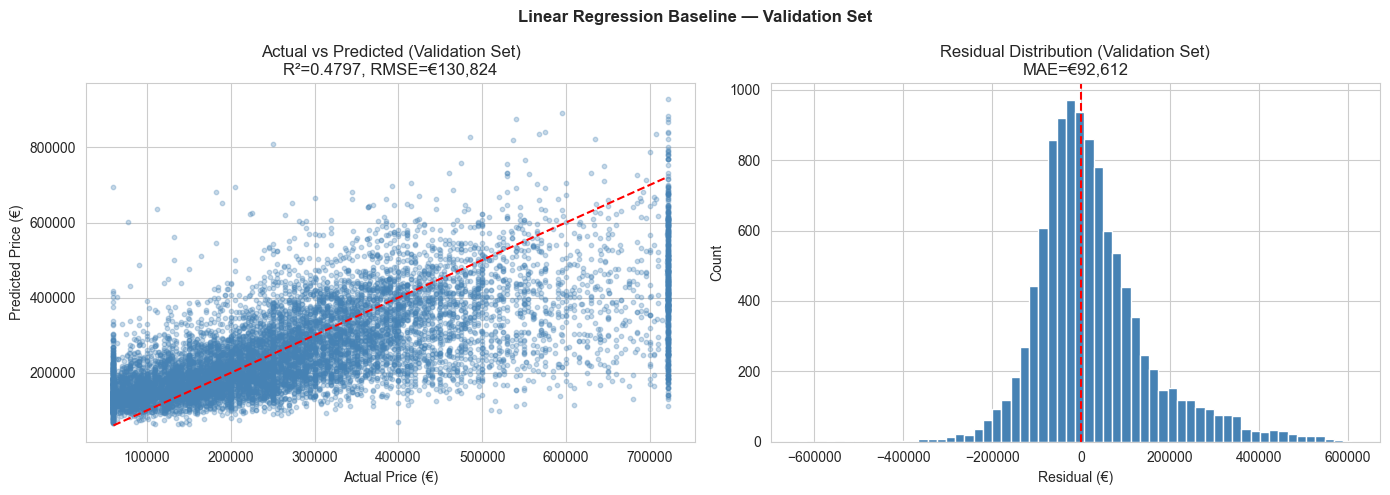

Mean residual : €24,393
Std residual  : €128,536


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Actual vs Predicted ---
axes[0].scatter(y_val_price, y_pred_val_price, alpha=0.3, s=10, color='steelblue')
axes[0].plot([y_val_price.min(), y_val_price.max()],
             [y_val_price.min(), y_val_price.max()], 'r--', linewidth=1.5)
axes[0].set_xlabel('Actual Price (€)')
axes[0].set_ylabel('Predicted Price (€)')
axes[0].set_title(f'Actual vs Predicted (Validation Set)\nR²={r2_val:.4f}, RMSE=€{rmse_val_price:,.0f}')

# --- Residuals distribution ---
residuals = y_val_price - y_pred_val_price
axes[1].hist(residuals, bins=60, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual (€)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Residual Distribution (Validation Set)\nMAE=€{mae_val_price:,.0f}')

plt.suptitle('Linear Regression Baseline — Validation Set', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Mean residual : €{residuals.mean():,.0f}")
print(f"Std residual  : €{residuals.std():,.0f}")

### 5.4 Cross-Validation

We use 5-fold cross-validation on the full training set to obtain a more robust estimate of model performance, reducing the variance introduced by a single train/validation split.

In [39]:
cv_scores = cross_val_score(
    LinearRegression(), X_encoded, y,
    cv=5, scoring='r2', n_jobs=-1
)

cv_rmse_scores = np.sqrt(-cross_val_score(
    LinearRegression(), X_encoded, y,
    cv=5, scoring='neg_mean_squared_error', n_jobs=-1
))

print("=== 5-Fold Cross-Validation Results ===")
print(f"\nR² per fold  : {[round(s, 4) for s in cv_scores]}")
print(f"R² mean      : {cv_scores.mean():.4f}")
print(f"R² std       : {cv_scores.std():.4f}")
print(f"\nRMSE per fold (log): {[round(s, 4) for s in cv_rmse_scores]}")
print(f"RMSE mean (log)    : {cv_rmse_scores.mean():.4f}")
print(f"RMSE std (log)     : {cv_rmse_scores.std():.4f}")

=== 5-Fold Cross-Validation Results ===

R² per fold  : [np.float64(0.4493), np.float64(0.4782), np.float64(0.46), np.float64(0.4207), np.float64(0.3758)]
R² mean      : 0.4368
R² std       : 0.0358

RMSE per fold (log): [np.float64(0.5141), np.float64(0.4759), np.float64(0.4683), np.float64(0.4676), np.float64(0.4605)]
RMSE mean (log)    : 0.4773
RMSE std (log)     : 0.0190


**Cross-Validation Findings:**

- The 5-fold cross-validation R² mean is **0.4368** (std = 0.036), slightly lower than the single validation split result of 0.4797. This is expected — cross-validation gives a more conservative and realistic estimate of generalisation performance.
- The R² scores across folds range from 0.376 to 0.478, indicating some variability depending on which data partition is used for validation. This suggests the model's performance is moderately sensitive to the data split.
- The consistent RMSE across folds (std = 0.019) confirms the model is **stable** — it does not dramatically overfit or underfit on any particular subset of the data.
- Taken together, the train R² (0.479), validation R² (0.480), and cross-validation R² (0.437) are all in a similar range, confirming **no significant overfitting**. The gap between training and CV performance is small and expected for a linear model.

### 5.5 Evaluation on External Test Set

We now apply the trained model to the held-out external test set (`test_data.csv`). The test set undergoes the **same cleaning pipeline** as the training set, using parameters fitted on the training data only (e.g., VAT rate, price clamping boundaries `p05`/`p95`, and the one-hot encoder) to prevent data leakage.

In [40]:
# --- Load test data ---
df_test_raw = pd.read_csv('test_data.csv')
print(f"Loaded: test_data.csv")
print(f"Shape: {df_test_raw.shape}")

df_test = df_test_raw.copy()

# --- Basic standardisation ---
str_cols_test = [c for c in df_test.columns if df_test[c].dtype == 'object']
for c in str_cols_test:
    df_test[c] = df_test[c].apply(clean_whitespace)

# --- Date parsing ---
df_test[date_col] = pd.to_datetime(df_test[date_col], dayfirst=True, errors='coerce')

# --- Price parsing ---
raw_price_test = df_test[price_col].astype(str).str.strip()
df_test[price_col] = pd.to_numeric(
    raw_price_test.str.replace('€', '', regex=False).str.replace(',', '', regex=False),
    errors='coerce'
)

# --- Temporal features ---
df_test['Sale Year']  = df_test[date_col].dt.year.astype('Int64')
df_test['Sale Month'] = df_test[date_col].dt.month.astype('Int64')

# --- is_apartment ---
df_test['is_apartment'] = df_test['Address'].str.contains(
    r'\b(apartment|apt|unit|flat)\b', case=False, na=False
).astype(int)

# --- location feature ---
df_test['location'] = df_test.apply(build_location, axis=1)

# --- Drop duplicates and invalid rows ---
df_test = df_test.drop_duplicates()
reject_mask_test = (
    df_test[price_col].isna() | (df_test[price_col] <= 0) |
    df_test[date_col].isna()
)
print(f"Rejected rows: {int(reject_mask_test.sum())}")
df_test = df_test.loc[~reject_mask_test].copy().reset_index(drop=True)

# --- VAT adjustment (use training VAT_RATE) ---
cond_test = (
    (df_test['Description of Property'].astype(str).str.strip() == 'New Dwelling house /Apartment') &
    (df_test['VAT Exclusive'].astype(str).str.strip().str.lower() == 'yes') &
    (df_test[price_col].notna())
)
df_test['Price_Adjusted_VAT'] = df_test[price_col].copy()
df_test.loc[cond_test, 'Price_Adjusted_VAT'] = df_test.loc[cond_test, price_col] * (1 + VAT_RATE)
df_test['vat_adjusted_flag'] = cond_test.astype(int)

# --- Price clamping (use training p05/p95) ---
df_test['Price_Final'] = df_test['Price_Adjusted_VAT'].clip(lower=p05, upper=p95)

# --- Log transform ---
df_test['Price_Log'] = np.log1p(df_test['Price_Final'])

print(f"Test shape after cleaning: {df_test.shape}")
display(df_test.head(3))

Loaded: test_data.csv
Shape: (10000, 14)
Rejected rows: 0
Test shape after cleaning: (9999, 22)


,Date of Sale (dd/mm/yyyy),Address,County,Eircode,Price (€),Not Full Market Price,VAT Exclusive,Description of Property,Property Size Description,geocode_status,latitude,longitude,geocode_provider,dublin_district,Sale Year,Sale Month,is_apartment,location,Price_Adjusted_VAT,vat_adjusted_flag,Price_Final,Price_Log
0,2025-12-15,"BALLYHOO, SCREEN, ENNISCORTHY",Wexford,Y21Y5P2,375000.00,No,No,Second-Hand Dwelling house /Apartment,NaN,NaN,NaN,NaN,NaN,NaN,2025,12,0,Wexford,375000.0000,0,375000.0000,12.834684
1,2025-11-11,"RATHREIGH, ARDAGH, CO. LIMERICK",Limerick,V42CF72,152000.00,No,No,Second-Hand Dwelling house /Apartment,NaN,NaN,NaN,NaN,NaN,NaN,2025,11,0,Limerick,152000.0000,0,152000.0000,11.931642
2,2025-12-02,"36 Woodword Court, Glencarin Gate, Murphystown...",Dublin,NaN,511150.12,No,Yes,New Dwelling house /Apartment,NaN,ok_mapbox_strict,53.263504,-6.207458,mapbox,18,2025,12,0,Dublin_18,580155.3862,1,580155.3862,13.271053


In [41]:
# --- Drop geocoding auxiliary columns and Address ---
drop_test_cols = ['geocode_status', 'latitude', 'longitude', 'geocode_provider', 'Address']
drop_test_cols = [c for c in drop_test_cols if c in df_test.columns]
df_test = df_test.drop(columns=drop_test_cols)

# --- Build location feature from County + dublin_district ---
df_test['location'] = df_test.apply(build_location, axis=1)

# --- Drop County and dublin_district ---
df_test = df_test.drop(columns=['County', 'dublin_district'], errors='ignore')

# --- Drop high-missingness columns ---
drop_high = ['Property Size Description', 'Eircode', date_col]
drop_high = [c for c in drop_high if c in df_test.columns]
df_test = df_test.drop(columns=drop_high)

print(f"Test shape after column cleaning: {df_test.shape}")
print("\nCurrent columns:", df_test.columns.tolist())

Test shape after column cleaning: (9999, 12)

Current columns: ['Price (€)', 'Not Full Market Price', 'VAT Exclusive', 'Description of Property', 'Sale Year', 'Sale Month', 'is_apartment', 'location', 'Price_Adjusted_VAT', 'vat_adjusted_flag', 'Price_Final', 'Price_Log']


In [42]:
# --- Build test feature matrix using training encoder ---
X_test_num = df_test[num_features].copy()
X_test_cat = df_test[cat_features].copy()

# Use training encoder — do NOT refit
X_test_cat_encoded = encoder.transform(X_test_cat)
X_test_cat_df = pd.DataFrame(X_test_cat_encoded, columns=cat_col_names, index=df_test.index)
X_test_final = pd.concat([X_test_num, X_test_cat_df], axis=1)

y_test_final = df_test['Price_Log']

# --- Predict ---
y_pred_test_log   = lr_model.predict(X_test_final)
y_pred_test_price = np.expm1(y_pred_test_log)
y_test_price      = np.expm1(y_test_final)

# --- Metrics ---
r2_test   = r2_score(y_test_final, y_pred_test_log)
rmse_test = np.sqrt(mean_squared_error(y_test_price, y_pred_test_price))
mae_test  = mean_absolute_error(y_test_price, y_pred_test_price)

print("=== External Test Set Evaluation ===")
print(f"\n{'Metric':<25} {'Train':>12} {'Validation':>12} {'Test':>12}")
print("-" * 65)
print(f"{'R²':<25} {r2_train:>12.4f} {r2_val:>12.4f} {r2_test:>12.4f}")
print(f"{'RMSE (€)':<25} {rmse_train_price:>12,.0f} {rmse_val_price:>12,.0f} {rmse_test:>12,.0f}")
print(f"{'MAE (€)':<25} {'':>12} {mae_val_price:>12,.0f} {mae_test:>12,.0f}")

=== External Test Set Evaluation ===

Metric                           Train   Validation         Test
-----------------------------------------------------------------
R²                              0.4792       0.4797       0.3704
RMSE (€)                       131,113      130,824      146,832
MAE (€)                                      92,612      109,869


**External Test Set Findings:**

- The model achieves an R² of **0.370** on the external test set, noticeably lower than the validation R² of 0.480. This drop suggests the external test set contains patterns not fully represented in the training data — likely because the test set contains more recent transactions (2025) that the model has not seen.
- The RMSE increases from **€131,000** (train) to **€147,000** (test), and MAE increases from **€93,000** (validation) to **€110,000** (test). This performance degradation on future data is expected for a time-sensitive domain like property prices.
- This is **not classical overfitting** — the train/validation gap is negligible. Rather, it reflects **temporal distribution shift**: the model was trained on 2016–2024 data and tested on 2025 data, where market conditions (prices, demand, supply) have continued to evolve.
- The results highlight the importance of including `Sale Year` as a feature and potentially retraining the model periodically with fresh data to maintain predictive accuracy.

### 5.6 Model Interpretation — Coefficient Analysis

One advantage of Linear Regression is its interpretability. Each coefficient represents the change in `Price_Log` (log-transformed price) associated with a one-unit increase in that feature, holding all other features constant. We examine the top features by absolute coefficient value to understand what drives property prices in this model.

Model intercept: -119.8729

Top 10 features (price increasing):


,feature,coefficient
9,location_Dublin,0.762582
30,location_Dublin_6,0.743103
15,location_Dublin_14,0.709530
31,location_Dublin_6W,0.698451
28,location_Dublin_4,0.672957
26,location_Dublin_27,0.647899
17,location_Dublin_16,0.583498
19,location_Dublin_18,0.567732
20,location_Dublin_2,0.562346
27,location_Dublin_3,0.416419



Top 10 features (price decreasing):


,feature,coefficient
47,location_Offaly,-0.455177
50,location_Tipperary,-0.511018
46,location_Monaghan,-0.569578
5,location_Cavan,-0.577680
49,location_Sligo,-0.586337
44,location_Mayo,-0.655572
42,location_Longford,-0.708737
8,location_Donegal,-0.709908
48,location_Roscommon,-0.713167
40,location_Leitrim,-0.746340


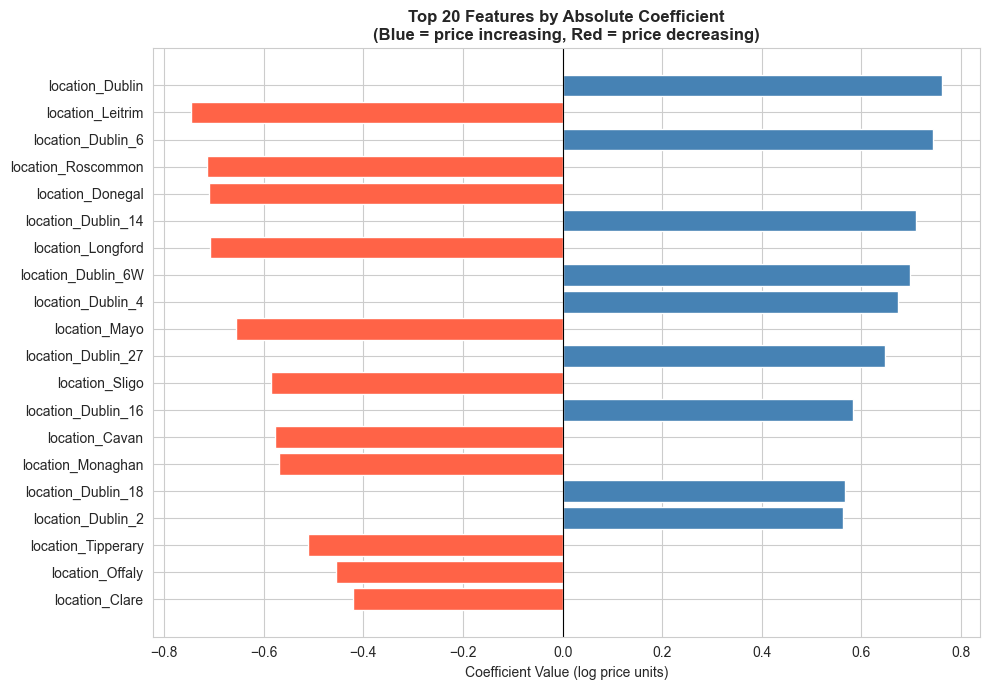

In [43]:
coef_df = pd.DataFrame({
    'feature'    : X_encoded.columns,
    'coefficient': lr_model.coef_
}).sort_values('coefficient', ascending=False)

print(f"Model intercept: {lr_model.intercept_:.4f}")

print("\nTop 10 features (price increasing):")
display(coef_df.head(10))

print("\nTop 10 features (price decreasing):")
display(coef_df.tail(10))

# --- Plot top 20 by absolute coefficient ---
top20 = coef_df.reindex(
    coef_df['coefficient'].abs().sort_values(ascending=False).index
).head(20)

colors = ['steelblue' if v > 0 else 'tomato' for v in top20['coefficient']]

plt.figure(figsize=(10, 7))
plt.barh(top20['feature'], top20['coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient Value (log price units)')
plt.title('Top 20 Features by Absolute Coefficient\n(Blue = price increasing, Red = price decreasing)',
          fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Model Interpretation — Key Findings:**

- **Location dominates the model**: all top 20 features by absolute coefficient are `location` categories, confirming that geography is by far the strongest predictor of property price in Ireland.
- **Price-increasing locations**: Dublin postal districts dominate the positive coefficients. `Dublin` (unspecified, +0.763), `Dublin_6` (+0.743), `Dublin_14` (+0.710), and `Dublin_6W` (+0.698) have the highest positive coefficients — consistent with the DQR finding that south Dublin commands a significant price premium.
- **Price-decreasing locations**: Rural western and border counties show the largest negative coefficients. `Leitrim` (-0.746), `Roscommon` (-0.713), `Donegal` (-0.710), and `Longford` (-0.709) are the strongest price-depressing locations — reflecting low demand and limited economic activity in these regions.
- Since coefficients are in **log price units**, a coefficient of +0.76 for `Dublin` means properties there are predicted to sell at approximately `e^0.76 ≈ 2.1×` the baseline price — roughly double the price of the reference location category.
- The `Sale Year`, `Sale Month`, `is_apartment`, and `vat_adjusted_flag` features have smaller coefficients relative to location, suggesting that **where** a property is located matters far more than **when** it was sold or **what type** it is in this linear model.